# Taksiran Nilai Agunan Properti (AVM): End-to-End Regresi

**Kasus bisnis:** untuk setiap pengajuan KPR atau kredit beragunan properti, bank perlu tahu **berapa nilai wajar agunannya**. Penilaian manual oleh appraiser mahal dan lama. Karena itu bank memakai **Automated Valuation Model (AVM)** untuk:
- taksiran awal sebelum appraisal fisik (*pre-screening*),
- menghitung **plafon maksimum** berdasarkan rasio LTV (*loan-to-value*),
- memantau nilai agunan portofolio dari waktu ke waktu (*revaluasi*).

**Target:** harga transaksi/appraisal (juta Rp). Model memprediksi **log(harga)**, karena error dalam persen (±10%) lebih bermakna daripada error dalam rupiah: salah Rp 100 jt untuk rumah Rp 5 M berbeda dengan salah Rp 100 jt untuk rumah Rp 500 jt.

| Tahap | Isi |
|---|---|
| Data & EDA | 10.000 transaksi properti 2022–2025, 10 kota, 16 fitur |
| Uji statistik fitur | Spearman, Kruskal-Wallis + ε², VIF (koreksi Holm) |
| Feature engineering di pipeline | **binning** umur bangunan & lebar jalan, **one-hot** kota/tipe/sertifikat, log1p luas & jarak, ordinal kondisi |
| 2 model | **Ridge** (linear) vs **Gradient Boosting**, keduanya dengan **penyesuaian tren harga** |
| Cross-validation | GridSearchCV, repeated K-fold 5×5 + corrected t-test, learning curve |
| Evaluasi statistik | RMSE, MdAPE, **PPE10/PPE20** (standar AVM), bootstrap CI, uji Diebold-Mariano & Wilcoxon |
| Diagnostik residual | normalitas, heteroskedastisitas (Breusch-Pagan), **Mincer-Zarnowitz**, bias per segmen |
| Interval prediksi | **conformal** 90%, diuji coverage-nya |
| Backtesting | **out-of-time** (Jul–Des 2025), **walk-forward** 12 kuartal, demonstrasi bias ekstrapolasi, PSI/CSI |
| Produksi | model JSON → FastAPI `/valuation` (taksiran + interval + plafon LTV) → Docker |

> Setiap cell kode didahului kotak **🔄 Alur data** (Input → Proses → Output → Berikutnya).

## 0. Peta Alur Data

```
 data/properties.csv (10.000 transaksi, Jan 2022 – Des 2025)
          │  + months_since_start (dari tanggal transaksi)
          ▼
 df ──────────────────────────► EDA (3) & uji statistik fitur (4): hanya dibaca
          │  split WAKTU
          ▼
 dev: Jan 2022 – Jun 2025                         OOT: Jul – Des 2025 ← dikunci sampai Bagian 15
     │  split ACAK 80/20
     ├──────────────► X_test (20% dev) ← dikunci sampai Bagian 12
     ▼
 X_train (80% dev)
     │  TrendAdjustedRegressor:  log(harga) = model(16 fitur) + g × (bulan − bulan_acuan)
     │     preprocess: binning + one-hot + log1p + scaling + ordinal   16 kolom ──► 36 kolom
     ▼
 GridSearchCV × 2 model (8) ──► repeated CV, uji signifikansi, learning curve (9) ──► model terbaik (10)
     │
     ├──► interval prediksi conformal dari residual out-of-fold (11)
     ▼
 Evaluasi X_test (12) ──► diagnostik residual & bias per segmen (13) ──► interpretasi (14)
     │
     ▼
 Backtesting (15): demonstrasi ekstrapolasi, out-of-time, walk-forward 12 kuartal, PSI/CSI
     │
     ▼
 Ringkasan (16) ──► refit SEMUA data + export model.json (17) ──► validasi (18) ──► API /valuation (19)
```

### Siklus hidup variabel utama

| Variabel | Bentuk | Dibuat | Dipakai | Isi |
|---|---|---|---|---|
| `df` | 10.000 × 19 + kolom bantu | Bagian 2 | 3–5, 15, 17 | Data mentah + `months_since_start`, `log_price`, `price_per_m2_land`, `quarter` |
| `dev`, `oot` | ±8.750 / ±1.250 | Bagian 5 | 5–17 | Periode pengembangan / out-of-time |
| `X_train`, `X_test` | ±7.000 / ±1.750 × 17 | Bagian 5 | 6–14 | 16 fitur + waktu |
| `y_*` | vektor | Bagian 5 | 6–15 | **log(harga)** |
| `searches` | 2 GridSearchCV | Bagian 8 | 9–12 | Hasil tuning |
| `rep_results` | dict | Bagian 9 | 9–10, 16 | 25 skor repeated CV per model |
| `best_model` | TrendAdjustedRegressor | Bagian 10 | 11–15 | Model terpilih (fit di X_train) |
| `Q_LOW`, `Q_HIGH` | float | Bagian 11 | 12–18, API | Kuantil residual conformal (interval 90%) |
| `test_pred` | vektor | Bagian 12 | 12–14 | Prediksi log di test |
| `walk_forward` | tabel | Bagian 15 | 15–16 | Hasil backtest per kuartal |
| `final_model` | TrendAdjustedRegressor | Bagian 17 | 17–18 | Model produksi (fit di **semua** data) |
| `model.json` | file | Bagian 17 | 18, API | Pipeline + tren + interval + metadata |

**Aturan yang dijaga:**
1. Semua yang dipelajari (median, mean/std, kategori, bobot, tren, kuantil interval) hanya dari data latih **pada tahap itu**.
2. `X_test` hanya dipakai untuk evaluasi akhir, dan OOT hanya dipakai untuk backtesting.
3. Setelah semua bukti terkumpul, model produksi dilatih ulang dengan **semua** data (Bagian 17). Konfigurasinya sama persis dengan yang sudah divalidasi, dan datanya lebih banyak serta paling baru.

## 1. Import & Konfigurasi

> **🔄 Alur data: Import & Konfigurasi**
>
> - **Input:** Belum ada data.
> - **Proses:**
>   1. Import library: pandas/numpy, matplotlib/seaborn, scipy (uji statistik), joblib (paralel), scikit-learn (Ridge, Gradient Boosting, CV, permutation importance).
>   2. Import modul proyek: `src/features.py` (fitur, binning, preprocessing, waktu), `src/model.py` (`TrendAdjustedRegressor`), `src/evaluation.py` (metrik AVM, bootstrap, Diebold-Mariano, Mincer-Zarnowitz, Breusch-Pagan, conformal, PSI), `src/json_model.py`.
>   3. Konstanta: `OOT_START = 2025-07-01`, `TEST_SIZE = 0,2`, `CV_FOLDS = 5`, interval 90%, dan kebijakan LTV ilustrasi (rumah/townhouse 80%, ruko 70%).
> - **Output:** Fungsi & konstanta siap dipakai.
> - **Berikutnya:** Baca data.

In [1]:
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from joblib import Parallel, delayed
from scipy import stats
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RepeatedKFold,
    cross_val_predict,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from src.evaluation import (  # noqa: E402
    bootstrap_ci,
    breusch_pagan,
    conformal_quantiles,
    corrected_mean_ci,
    corrected_resampled_ttest,
    holm_correction,
    interval_coverage,
    kruskal_epsilon,
    mincer_zarnowitz,
    paired_error_tests,
    psi_categorical,
    psi_numeric,
    regression_metrics,
    residual_normality,
    segment_bias,
    stability_label,
    vif,
)
from src.features import (  # noqa: E402
    BINARY_COLS,
    DATE_COL,
    DOMAIN_BINS,
    FEATURES,
    ID_COL,
    LOG_COLS,
    MODEL_INPUT,
    NUM_COLS,
    ONEHOT_COLS,
    ORDINAL_COLS,
    TARGET,
    TIME_COL,
    add_time,
    build_preprocessor,
)
from src.json_model import JsonValuationModel, export_model, save_json  # noqa: E402
from src.model import TrendAdjustedRegressor  # noqa: E402

RANDOM_STATE = 42
OOT_START = "2025-07-01"          # Jul–Des 2025 = out-of-time
TEST_SIZE = 0.2
CV_FOLDS = 5
INTERVAL_COVERAGE = 0.90
LTV_POLICY = {"rumah": 0.80, "townhouse": 0.80, "ruko": 0.70}   # ilustrasi; ikuti kebijakan internal & ketentuan BI
NUMERIC_ALL = list(DOMAIN_BINS) + LOG_COLS + NUM_COLS

DATA_PATH = PROJECT_DIR / "data" / "properties.csv"
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 250)
print(f"Python {platform.python_version()} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

Python 3.14.6 | scikit-learn 1.9.1 | pandas 3.0.6


## 2. Load Data

> **🔄 Alur data: Load Data & Kolom Bantu**
>
> - **Input:** `data/properties.csv`.
> - **Proses:**
>   1. `pd.read_csv` lalu `add_time`: `months_since_start` = bulan (pecahan) sejak 1 Jan 2022.
>   2. `log_price` = log(harga), yaitu **target model**. `price_per_m2_land` = harga ÷ luas tanah (hanya untuk EDA).
> - **Output:** `df` (**10.000 × 22**): 19 kolom asli + `months_since_start` + `log_price` + `price_per_m2_land`.
> - **Berikutnya:** Cek skema.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} belum ada. Jalankan dulu: python scripts/generate_data.py")
df = add_time(pd.read_csv(DATA_PATH))
df["log_price"] = np.log(df[TARGET])
df["price_per_m2_land"] = df[TARGET] / df["land_area"]
print(df.shape)
df.head()

(10000, 22)


,property_id,transaction_date,city,property_type,land_area,building_area,floors,bedrooms,bathrooms,carport,building_age,condition,certificate,road_width_m,distance_to_cbd_km,near_toll,near_transit,flood_prone,price,months_since_start,log_price,price_per_m2_land
0,P000354,2022-01-02,bogor,rumah,195.0,290.0,2,7,5,1,9.0,sedang,HGB,2.5,23.0,0,0,0,1217.3,0.032854,7.104391,6.242564
1,P000369,2022-01-02,tangerang_selatan,ruko,140.0,369.0,3,6,5,2,25.0,sedang,SHM,10.0,14.0,1,0,0,1832.3,0.032854,7.513327,13.087857
2,P001438,2022-01-02,depok,rumah,90.0,87.0,2,2,2,1,8.0,baik,SHM,2.8,8.2,1,0,0,984.8,0.032854,6.892439,10.942222
3,P001464,2022-01-02,tangerang_selatan,ruko,123.0,203.0,3,4,4,1,2.0,baik,SHM,10.0,9.4,1,0,0,2148.3,0.032854,7.672432,17.465854
4,P001711,2022-01-02,surabaya,townhouse,144.0,184.0,2,4,3,2,1.0,baik,girik_ajb,5.3,16.1,0,1,0,1813.2,0.032854,7.502849,12.591667


### Kamus Data (16 fitur)

| Kolom | Tipe | Keterangan | Perlakuan di pipeline |
|---|---|---|---|
| `building_age` | numerik | Umur bangunan (tahun), ±5% kosong | **Binning**: baru 0–5 / 6–15 / 16–30 / tua > 30 / missing → one-hot |
| `road_width_m` | numerik | Lebar jalan akses (m), ±3% kosong | **Binning**: gang < 3 m / sedang 3–6 m / lebar > 6 m / missing → one-hot |
| `land_area` | numerik | Luas tanah (m²) | log1p → scaling |
| `building_area` | numerik | Luas bangunan (m²) | log1p → scaling |
| `distance_to_cbd_km` | numerik | Jarak ke pusat kota (km) | log1p → scaling |
| `floors`, `bedrooms`, `bathrooms`, `carport` | numerik | Jumlah lantai, kamar tidur, kamar mandi, kapasitas carport | scaling |
| `near_toll`, `near_transit`, `flood_prone` | biner | Dekat akses tol / transportasi massal (KRL/MRT/LRT), rawan banjir | apa adanya (0/1) |
| `condition` | ordinal | perlu_renovasi < sedang < baik | ordinal 0/1/2 |
| `city` | kategorikal | 10 kota | **one-hot** |
| `property_type` | kategorikal | rumah / townhouse / ruko | **one-hot** |
| `certificate` | kategorikal | SHM / HGB / girik_ajb | **one-hot** |
| `transaction_date` | tanggal | Tanggal transaksi/appraisal | → `months_since_start` (penyesuaian tren) |
| **`price`** | target | Harga (juta Rp) | model memprediksi **log(price)** |

**Kenapa binning untuk umur bangunan dan lebar jalan?** Pengaruh keduanya tidak linear dan mengikuti “ambang” yang dikenal appraiser. Rumah 0–5 tahun dianggap baru, sedangkan > 30 tahun biasanya hanya dinilai tanahnya. Jalan < 3 m (gang) tidak bisa dilalui mobil, sehingga nilainya turun tajam, sedangkan 6 m vs 10 m bedanya kecil. Binning membuat model linear pun bisa menangkap pola ambang ini, dan nilai kosong punya kategori sendiri.

> **🔄 Alur data: Validasi Skema**
>
> - **Input:** `df`.
> - **Proses:**
>   1. `assert`: semua 16 fitur, ID, tanggal, dan harga ada; ID unik; harga > 0.
>   2. `info()` untuk tipe & jumlah nilai terisi.
> - **Output:** Skema valid. Kosong: `building_age` 9.527 terisi (4,7% kosong), `road_width_m` 9.716 terisi (2,8% kosong).
> - **Berikutnya:** Hitung kualitas data.

In [3]:
assert set(FEATURES + [ID_COL, DATE_COL, TARGET]) <= set(df.columns)
assert df[ID_COL].is_unique and (df[TARGET] > 0).all()
df[FEATURES + [TARGET]].info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   building_age        9527 non-null   float64
 1   road_width_m        9716 non-null   float64
 2   land_area           10000 non-null  float64
 3   building_area       10000 non-null  float64
 4   distance_to_cbd_km  10000 non-null  float64
 5   floors              10000 non-null  int64  
 6   bedrooms            10000 non-null  int64  
 7   bathrooms           10000 non-null  int64  
 8   carport             10000 non-null  int64  
 9   near_toll           10000 non-null  int64  
 10  near_transit        10000 non-null  int64  
 11  flood_prone         10000 non-null  int64  
 12  condition           10000 non-null  str    
 13  city                10000 non-null  str    
 14  property_type       10000 non-null  str    
 15  certificate         10000 non-null  str    
 16  price           

## 3. Exploratory Data Analysis

> **🔄 Alur data: Kualitas Data & Statistik Ringkas**
>
> - **Input:** `df`.
> - **Proses:**
>   1. % missing, jumlah nilai unik, duplikat.
>   2. Statistik deskriptif kolom numerik, harga, dan harga/m² tanah.
> - **Output:** Duplikat 0. Median harga Rp 1.153 jt (rentang 130 jt – 11,1 M), median luas tanah 102 m², bangunan 106 m², umur bangunan 12 tahun, jarak ke CBD 12,8 km, harga/m² tanah median Rp 11 jt.
> - **Berikutnya:** Lihat distribusi harga.

In [4]:
quality = pd.DataFrame({
    "dtype": df[FEATURES + [TARGET]].dtypes.astype(str),
    "missing_%": (df[FEATURES + [TARGET]].isna().mean() * 100).round(2),
    "n_unique": df[FEATURES + [TARGET]].nunique(),
})
print("Duplikat:", int(df.duplicated(subset=FEATURES + [TARGET]).sum()))
display(quality.T)
df[NUMERIC_ALL + [TARGET, "price_per_m2_land"]].describe().T.round(2)

Duplikat: 0


,building_age,road_width_m,land_area,building_area,distance_to_cbd_km,floors,bedrooms,bathrooms,carport,near_toll,near_transit,flood_prone,condition,city,property_type,certificate,price
dtype,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,str,str,str,str,float64
missing_%,4.73,2.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
n_unique,61,162,367,473,281,4,11,8,7,2,2,2,3,10,3,3,8142


,count,mean,std,min,25%,50%,75%,max
building_age,9527.0,13.58,9.53,0.00,7.00,12.00,18.00,60.00
road_width_m,9716.0,5.93,2.67,1.50,4.00,5.40,7.30,20.00
land_area,10000.0,117.75,60.73,30.00,76.00,102.00,142.00,841.00
building_area,10000.0,127.26,82.94,21.00,73.00,106.00,159.00,895.00
distance_to_cbd_km,10000.0,13.16,6.56,2.00,7.60,12.80,18.00,30.00
floors,10000.0,1.89,0.76,1.00,1.00,2.00,2.00,4.00
bedrooms,10000.0,3.20,2.17,0.00,2.00,3.00,4.00,10.00
bathrooms,10000.0,2.74,1.76,1.00,1.00,2.00,4.00,8.00
carport,10000.0,1.32,0.92,0.00,1.00,1.00,2.00,6.00
price,10000.0,1416.08,982.55,129.80,771.00,1153.35,1748.98,11087.40


> **🔄 Alur data: Distribusi Harga & Harga per Kota**
>
> - **Input:** `df[price]`, `df[log_price]`, `df[price_per_m2_land]`.
> - **Proses:**
>   1. Histogram harga mentah vs log, lalu boxplot harga/m² tanah per kota (diurutkan dari median).
> - **Output:** Grafik. Skewness harga 2,47 → log 0,14. Harga/m² tanah per kota: Bogor Rp 7,3 jt (termurah) s.d. Jakarta Selatan Rp 23 jt.
> - **Berikutnya:** Lihat hubungan luas–harga & tren waktu.

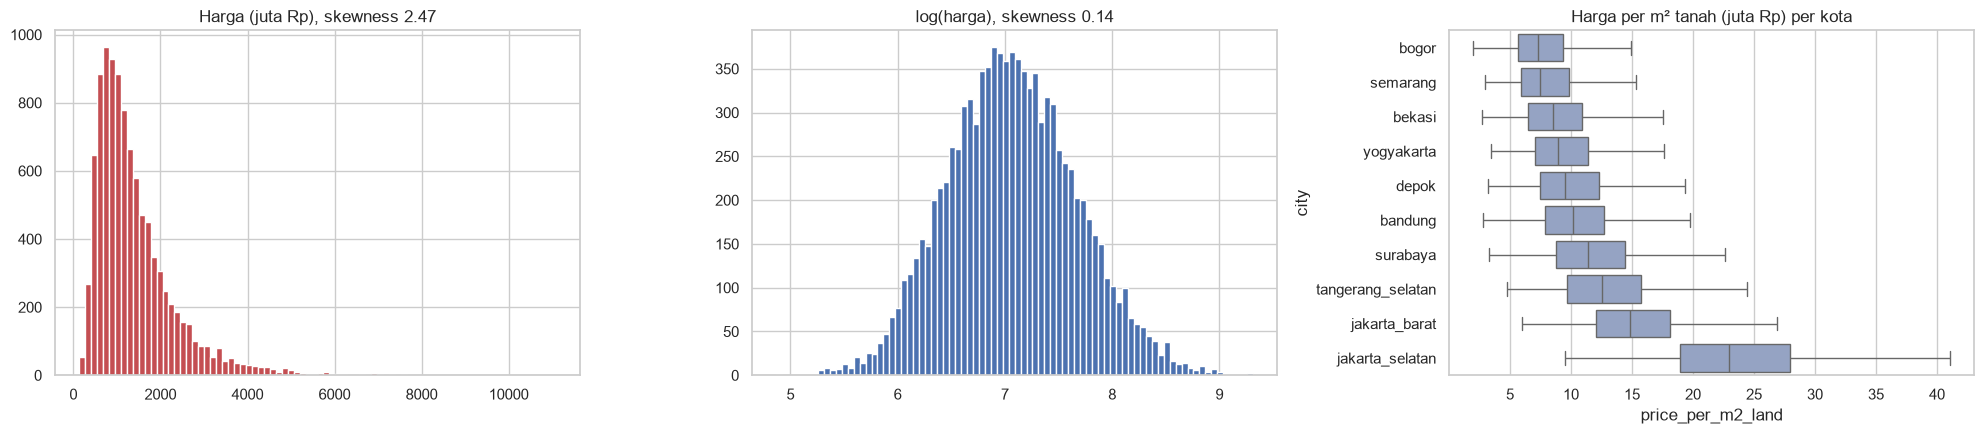

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
axes[0].hist(df[TARGET], bins=80, color="#C44E52")
axes[0].set_title(f"Harga (juta Rp), skewness {df[TARGET].skew():.2f}")
axes[1].hist(df["log_price"], bins=80, color="#4C72B0")
axes[1].set_title(f"log(harga), skewness {df['log_price'].skew():.2f}")
order = df.groupby("city")["price_per_m2_land"].median().sort_values().index
sns.boxplot(data=df, y="city", x="price_per_m2_land", order=order, ax=axes[2], showfliers=False, color="#8DA0CB")
axes[2].set_title("Harga per m² tanah (juta Rp) per kota")
plt.tight_layout()
plt.show()

> **🔄 Alur data: Luas vs Harga & Indeks Harga**
>
> - **Input:** `df`.
> - **Proses:**
>   1. Scatter log-log luas tanah vs harga per tipe properti.
>   2. Kolom `quarter` ditambahkan ke `df`. Median harga/m² per kuartal per kota dijadikan indeks (2022Q1 = 100).
> - **Output:** Grafik. Log-log luas–harga mendekati garis lurus dengan sebaran lebar (efek lokasi). Indeks semua kota naik ±25% dari 2022Q1 ke 2025Q4.
> - **Berikutnya:** Lihat efek fitur kategorikal & hasil binning.

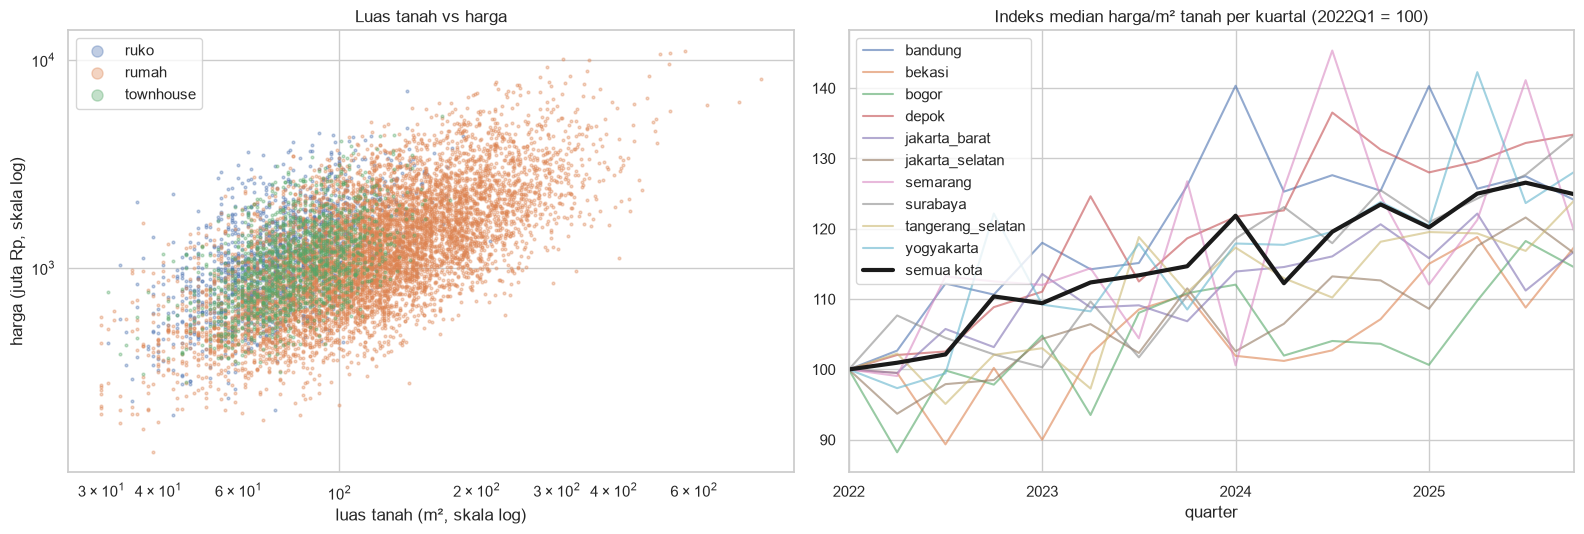

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ptype, g in df.groupby("property_type"):
    axes[0].scatter(g["land_area"], g[TARGET], s=4, alpha=0.35, label=ptype)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("luas tanah (m², skala log)")
axes[0].set_ylabel("harga (juta Rp, skala log)")
axes[0].set_title("Luas tanah vs harga")
axes[0].legend(markerscale=4)

df["quarter"] = pd.PeriodIndex(df[DATE_COL], freq="Q")
idx = df.groupby(["quarter", "city"])["price_per_m2_land"].median().unstack()
(idx / idx.iloc[0] * 100).plot(ax=axes[1], legend=False, alpha=0.6)
(df.groupby("quarter")["price_per_m2_land"].median() / df.groupby("quarter")["price_per_m2_land"].median().iloc[0] * 100).plot(
    ax=axes[1], color="k", lw=3, label="semua kota")
axes[1].set_title("Indeks median harga/m² tanah per kuartal (2022Q1 = 100)")
axes[1].legend()
plt.tight_layout()
plt.show()

> **🔄 Alur data: Efek Binning & Kategori**
>
> - **Input:** `df`.
> - **Proses:**
>   1. `binned` = salinan `df` + `building_age_bin` & `road_width_m_bin` (batas yang **sama** dengan pipeline, NaN → `missing`).
>   2. Median harga/m² tanah per kategori untuk 8 fitur.
> - **Output:** `binned` + grafik. Median harga/m²: bangunan baru 12,2 vs tua 8,1 jt; jalan > 6 m 12,3 vs gang 9,4 jt; kondisi baik 11,8 vs perlu renovasi 8,7 jt; dekat transit 13,0 vs 10,4 jt.
> - **Berikutnya:** Uji statistik.

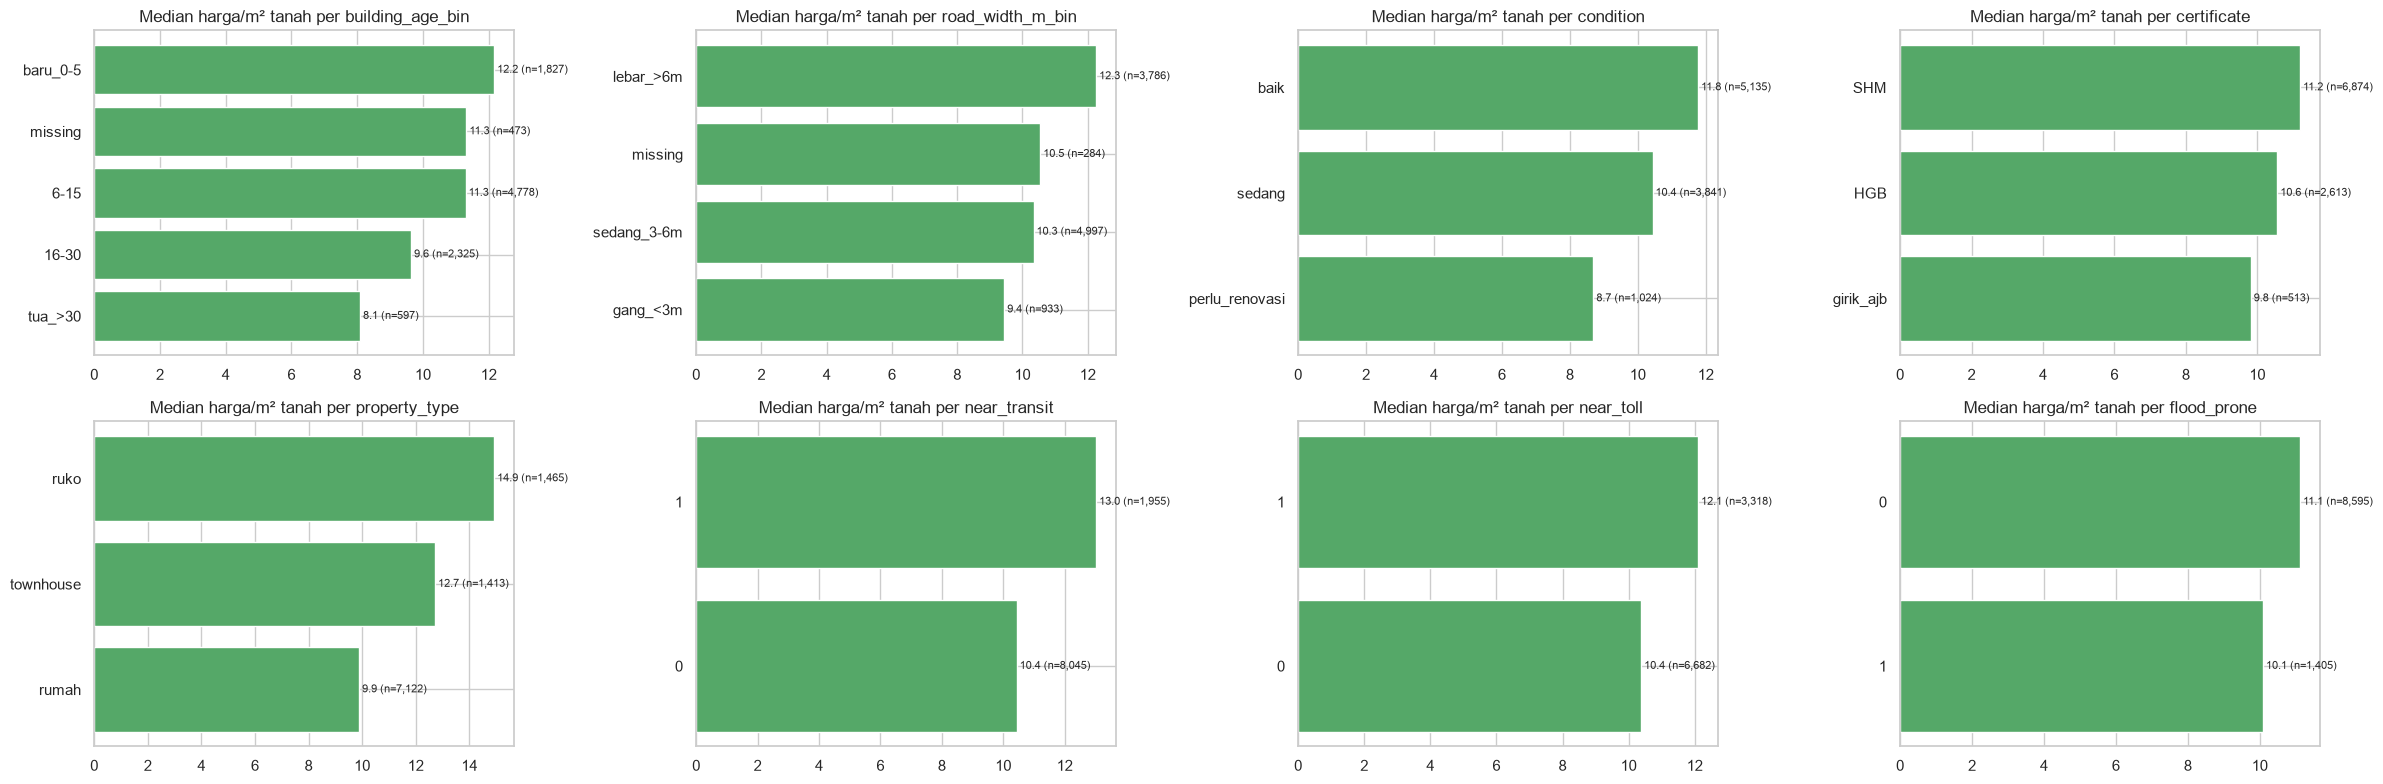

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(24, 8))
binned = df.assign(**{f"{c}_bin": pd.cut(df[c], s["edges"], labels=s["labels"]).astype(object).fillna("missing") for c, s in DOMAIN_BINS.items()})
for ax, col in zip(axes.ravel(), ["building_age_bin", "road_width_m_bin", "condition", "certificate",
                                  "property_type", "near_transit", "near_toll", "flood_prone"]):
    stat = binned.groupby(col)["price_per_m2_land"].agg(["median", "size"]).sort_values("median")
    ax.barh(stat.index.astype(str), stat["median"], color="#55A868")
    for y_, (m, n) in enumerate(stat.values):
        ax.text(m, y_, f" {m:.1f} (n={int(n):,})", va="center", fontsize=8)
    ax.set_title(f"Median harga/m² tanah per {col}")
plt.tight_layout()
plt.show()

### Insight EDA

- **Harga sangat miring**: skewness harga mentah 2,47, sedangkan log(harga) hanya 0,14 (hampir simetris). Ini alasan target dimodelkan dalam **log**, sehingga error dibaca dalam persen dan rumah Rp 10 M tidak mendominasi pelatihan.
- **Lokasi adalah faktor terbesar**: median harga/m² tanah berkisar dari **Rp 7,3 jt (Bogor)** sampai **Rp 23 jt (Jakarta Selatan)**, atau lebih dari 3 kali lipat untuk luas yang sama.
- **Hubungan luas–harga mendekati linear di skala log-log**, tetapi menyebar lebar karena lokasi. Model perlu menangkap **interaksi luas × lokasi**, dan ini keunggulan model berbasis pohon.
- **Tren harga**: indeks median harga/m² naik ±25% dari 2022Q1 ke 2025Q4, dengan fluktuasi antar kuartal (komposisi properti yang terjual berbeda-beda).
- **Efek binning dan kategori sesuai logika appraisal** (median harga/m² tanah):
  - umur bangunan: baru 0–5 th Rp 12,2 jt → 6–15 th 11,3 → 16–30 th 9,6 → tua > 30 th **8,1 jt**
  - lebar jalan: gang < 3 m Rp 9,4 jt vs > 6 m **12,3 jt**
  - kondisi: perlu renovasi 8,7 → sedang 10,4 → baik 11,8
  - sertifikat: SHM 11,2 vs girik/AJB 9,8
  - dekat transit 13,0 vs 10,4; rawan banjir 10,1 vs 11,1
- Missing hanya di `building_age` (4,7%) dan `road_width_m` (2,8%). Keduanya jadi kategori `missing` di binning, sehingga tidak ada data yang dibuang.

## 4. Uji Statistik Fitur

| Uji | Untuk | Besar efek |
|---|---|---|
| **Spearman ρ** | fitur numerik/biner vs log(harga) | ρ: < 0,1 sangat kecil, 0,1–0,3 kecil, 0,3–0,5 sedang, ≥ 0,5 besar |
| **Kruskal-Wallis H** | fitur kategorikal & hasil binning vs log(harga) | ε²: < 0,01 sangat kecil, 0,01–0,08 kecil, 0,08–0,26 sedang, ≥ 0,26 besar |
| **VIF** | multikolinearitas antar fitur numerik | > 5 sedang, > 10 tinggi |

Semua p-value dikoreksi Holm. Uji dilakukan pada seluruh data sebagai eksplorasi. Tidak ada fitur yang dibuang berdasarkan hasil ini.

> **🔄 Alur data: Uji Statistik Fitur & VIF**
>
> - **Input:** `df` / `binned`.
> - **Proses:**
>   1. Spearman ρ untuk 9 numerik + 3 biner vs log(harga); Kruskal-Wallis + ε² untuk 2 kolom bin, kondisi, kota, tipe, dan sertifikat.
>   2. Koreksi Holm, lalu VIF antar 9 fitur numerik.
> - **Output:** `feature_tests` (18 baris): semua signifikan. Efek besar: `building_area` ρ 0,60, `land_area` 0,59, `city` ε² 0,29. `vif_table`: `bedrooms` 13,8 (tinggi), `bathrooms` 9,2 & `building_area` 8,4 (sedang).
> - **Berikutnya:** Data dibagi.

In [8]:
rows = []
for col in NUMERIC_ALL + BINARY_COLS:
    d = df[[col, "log_price"]].dropna()
    rho, p = stats.spearmanr(d[col], d["log_price"])
    rows.append({"fitur": col, "uji": "Spearman", "statistik": rho, "p_value": p, "besar_efek": abs(rho),
                 "kategori_efek": pd.cut([abs(rho)], [0, 0.1, 0.3, 0.5, 1], labels=["sangat kecil", "kecil", "sedang", "besar"], include_lowest=True)[0]})
for col in ["building_age_bin", "road_width_m_bin", "condition"] + ONEHOT_COLS:
    h, p, eps2 = kruskal_epsilon(binned["log_price"], binned[col])
    rows.append({"fitur": col, "uji": "Kruskal-Wallis", "statistik": h, "p_value": p, "besar_efek": eps2,
                 "kategori_efek": pd.cut([eps2], [0, 0.01, 0.08, 0.26, 1], labels=["sangat kecil", "kecil", "sedang", "besar"], include_lowest=True)[0]})
feature_tests = pd.DataFrame(rows).set_index("fitur")
feature_tests["p_holm"] = holm_correction(feature_tests["p_value"])
feature_tests["signifikan"] = np.where(feature_tests["p_holm"] < 0.05, "ya", "tidak")
display(feature_tests.sort_values(["uji", "besar_efek"], ascending=[False, False]).round(4))

vif_table = vif(df[NUMERIC_ALL]).to_frame()
vif_table["status"] = pd.cut(vif_table["VIF"], [0, 5, 10, np.inf], labels=["aman", "sedang", "tinggi"])
display(vif_table.round(2))

,uji,statistik,p_value,besar_efek,kategori_efek,p_holm,signifikan
fitur,,,,,,,
building_area,Spearman,0.6022,0.0,0.6022,besar,0.0,ya
land_area,Spearman,0.5936,0.0,0.5936,besar,0.0,ya
bedrooms,Spearman,0.5603,0.0,0.5603,besar,0.0,ya
bathrooms,Spearman,0.5295,0.0,0.5295,besar,0.0,ya
carport,Spearman,0.3927,0.0,0.3927,sedang,0.0,ya
distance_to_cbd_km,Spearman,-0.3818,0.0,0.3818,sedang,0.0,ya
building_age,Spearman,-0.1596,0.0,0.1596,kecil,0.0,ya
near_transit,Spearman,0.1477,0.0,0.1477,kecil,0.0,ya
floors,Spearman,0.1205,0.0,0.1205,kecil,0.0,ya


,VIF,status
bedrooms,13.82,tinggi
bathrooms,9.18,sedang
building_area,8.44,sedang
land_area,4.39,aman
floors,2.59,aman
carport,2.01,aman
road_width_m,1.17,aman
building_age,1.00,aman
distance_to_cbd_km,1.00,aman


### Interpretasi Uji Statistik Fitur

- **Semua 18 uji signifikan** setelah koreksi Holm (n = 10.000, sehingga efek kecil pun signifikan). Yang membedakan adalah **besar efeknya**.
- **Efek besar**:
  - ukuran properti: `building_area` (ρ = 0,60), `land_area` (0,59), `bedrooms` (0,56), `bathrooms` (0,53)
  - lokasi: `city` (ε² = 0,29, terbesar di antara kategorikal)
- **Efek sedang**: `distance_to_cbd_km` (ρ = −0,38; makin jauh makin murah) dan `carport` (0,39).
- **Efek kecil tapi relevan**: umur bangunan (ρ = −0,16), dekat transit (0,15), dekat tol (0,12), kondisi, dan tipe properti. Dalam rupiah, efek ini tetap bernilai puluhan hingga ratusan juta.
- **Sangat kecil secara marginal**: `flood_prone`, `road_width_m`, sertifikat. Namun efek marginal bisa menipu. Rawan banjir menurunkan nilai tanah ±15% di generator data, tetapi korelasinya kecil karena tertutup variasi luas dan lokasi yang jauh lebih besar. Model multivariat (Bagian 14) bisa memisahkannya.
- **VIF**: `bedrooms` (13,8) tinggi, `bathrooms` (9,2) dan `building_area` (8,4) sedang. Jumlah kamar praktis ditentukan oleh luas bangunan. Ini tidak mengganggu Gradient Boosting, dan Ridge menanganinya lewat regularisasi. Konsekuensinya, kontribusi individual ketiga fitur tidak bisa ditafsirkan terpisah (terlihat di permutation importance: `bedrooms`/`bathrooms` ≈ 0 karena informasinya sudah diwakili `building_area`).

## 5. Split Data: Waktu (dev vs OOT) lalu Acak (train vs test)

1. **Split waktu**: transaksi sebelum 1 Jul 2025 = **dev**; Jul–Des 2025 = **out-of-time (OOT)**, disimpan untuk backtesting (Bagian 15).
2. **Split acak** di dalam dev: 80% **train** (tuning & training), 20% **test** (evaluasi akhir).

> **🔄 Alur data: Split Waktu & Split Acak**
>
> - **Input:** `df`.
> - **Proses:**
>   1. Split waktu: `dev` (< Jul 2025), `oot` (Jul–Des 2025).
>   2. `X_*` = 16 fitur + `months_since_start`; `y_*` = log(harga).
>   3. Di dalam dev: `train_test_split` 80/20 acak.
> - **Output:** `dev` 8.761, `oot` 1.239; `X_train` 7.008 × 17, `X_test` 1.753 × 17. Median harga train Rp 1.131 jt, test 1.162 jt, OOT 1.250 jt (lebih tinggi karena tren).
> - **Berikutnya:** `X_test` dikunci sampai Bagian 12, `oot` sampai Bagian 15.

In [9]:
dev = df[df[DATE_COL] < OOT_START].reset_index(drop=True)
oot = df[df[DATE_COL] >= OOT_START].reset_index(drop=True)
X_dev, y_dev = dev[MODEL_INPUT], dev["log_price"]
X_oot, y_oot = oot[MODEL_INPUT], oot["log_price"]
X_train, X_test, y_train, y_test = train_test_split(X_dev, y_dev, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"dev   : {len(dev):,} ({dev[DATE_COL].min()} – {dev[DATE_COL].max()})")
print(f"OOT   : {len(oot):,} ({oot[DATE_COL].min()} – {oot[DATE_COL].max()})")
print(f"train : {X_train.shape} | test: {X_test.shape}")
print(f"median harga: train {np.exp(y_train.median()):,.0f} | test {np.exp(y_test.median()):,.0f} | OOT {np.exp(y_oot.median()):,.0f} juta")

dev   : 8,761 (2022-01-02 – 2025-06-30)
OOT   : 1,239 (2025-07-03 – 2025-12-29)
train : (7008, 17) | test: (1753, 17)
median harga: train 1,131 | test 1,162 | OOT 1,250 juta


## 6. Pipeline Preprocessing

```
domain_bin : building_age, road_width_m → DomainBinner (batas appraisal; NaN → 'missing') → one-hot
log_num    : land_area, building_area, distance_to_cbd_km → isi median → log1p → StandardScaler
num        : floors, bedrooms, bathrooms, carport → isi median → StandardScaler
binary     : near_toll, near_transit, flood_prone → isi modus → apa adanya
ordinal    : condition → perlu_renovasi=0, sedang=1, baik=2 (nilai tak dikenal → median)
onehot     : city, property_type, certificate → isi modus → one-hot (kategori baru → semua 0)
```

Kolom waktu `months_since_start` **tidak** masuk preprocessing. Waktu ditangani oleh `TrendAdjustedRegressor` (Bagian 7).

> **🔄 Alur data: Fit Preprocessor (Inspeksi)**
>
> - **Input:** `X_train[FEATURES]` (16 kolom, tanpa waktu).
> - **Proses:**
>   1. `fit` mempelajari median, mean/std, modus, dan daftar kategori **dari X_train**; `transform` menerapkannya.
>   2. Jumlah kolom hasil per blok transformer dihitung.
> - **Output:** `Z_train` (7.008 × **36**): one-hot 16, bin 9, numerik 4, log 3, biner 3, ordinal 1.
> - **Berikutnya:** Telusuri 1 properti.

In [10]:
preprocessor = build_preprocessor()
Z_train = pd.DataFrame(preprocessor.fit_transform(X_train[FEATURES]), columns=preprocessor.get_feature_names_out(), index=X_train.index)
print(f"{len(FEATURES)} fitur mentah → {Z_train.shape[1]} kolom")
print(pd.Series(Z_train.columns).str.split("__").str[0].value_counts().to_string())

16 fitur mentah → 36 kolom
onehot        16
domain_bin     9
num            4
log_num        3
binary         3
ordinal        1


> **🔄 Alur data: Telusuri 1 Properti**
>
> - **Input:** Baris pertama X_train dan hasil transformasinya.
> - **Proses:**
>   1. Nilai mentah ditampilkan, lalu kolom hasil yang tidak bernilai 0.
> - **Output:** Contoh rumah Bandung 63 m² (umur 21 th, jalan 4,3 m, HGB): `building_age_bin_16-30` = 1, `road_width_m_bin_sedang_3-6m` = 1, luas tanah −1,13 std, `condition` = 2 (baik), `city_bandung` = 1. Hanya 14 dari 36 kolom yang tidak bernilai 0.
> - **Berikutnya:** Definisikan model.

In [11]:
contoh = X_train.iloc[[0]]
display(contoh.T.rename(columns={contoh.index[0]: "nilai_mentah"}))
z = Z_train.iloc[0]
print(f"Kolom hasil transformasi yang tidak bernilai 0: {(z != 0).sum()} dari {len(z)}")
display(z[z != 0].to_frame("nilai_transformasi").round(4))

,nilai_mentah
building_age,21.0
road_width_m,4.3
land_area,63.0
building_area,53.0
distance_to_cbd_km,8.7
floors,1
bedrooms,1
bathrooms,1
carport,0
near_toll,1


Kolom hasil transformasi yang tidak bernilai 0: 14 dari 36


,nilai_transformasi
domain_bin__building_age_bin_16-30,1.0000
domain_bin__road_width_m_bin_sedang_3-6m,1.0000
log_num__land_area,-1.1323
log_num__building_area,-1.1844
log_num__distance_to_cbd_km,-0.4744
num__floors,-1.1764
num__bedrooms,-1.0097
num__bathrooms,-0.9858
num__carport,-1.4184
binary__near_toll,1.0000


## 7. Dua Model & Penyesuaian Tren Harga

| | **Ridge** | **Gradient Boosting** |
|---|---|---|
| Bentuk | log(harga) = Σ bobot × fitur | penjumlahan ratusan pohon keputusan kecil |
| Menangkap | efek aditif (dalam persen); pola ambang lewat binning | interaksi & non-linearitas otomatis (mis. luas tanah × kota) |
| Kelebihan | sederhana, transparan (bobot = % efek), cepat | biasanya lebih akurat untuk data properti |
| Kekurangan | tidak bisa menangkap interaksi kecuali dibuat manual | lebih sulit dijelaskan, model lebih besar |

### Masalah waktu: model pohon tidak bisa mengekstrapolasi

Harga properti naik setiap bulan. Jika waktu dijadikan fitur biasa, model berbasis pohon akan memberi prediksi **yang sama** untuk semua tanggal setelah data latih terakhir, karena pohon hanya bisa memilih nilai yang pernah dilihatnya. Akibatnya, agunan yang dinilai 6 bulan kemudian **ditaksir terlalu rendah**.

**Solusi: `TrendAdjustedRegressor`** (`src/model.py`), teknik *indexing* yang lazim di AVM:
1. Estimasi tren pasar **g** (log-harga per bulan) dengan regresi hedonik linear: log(harga) ~ fitur + g × bulan.
2. Ubah target ke level harga **bulan acuan** (bulan terakhir data latih): y_adj = log(harga) − g × (bulan − bulan_acuan).
3. Latih model (Ridge atau GBR) pada y_adj **tanpa** fitur waktu.
4. Prediksi = model(fitur) + g × (bulan_valuasi − bulan_acuan).

Kedua kandidat memakai pembungkus yang sama, jadi perbandingannya adil. Cell berikutnya membuktikan masalahnya dengan **mini-backtest di dalam dev** (latih 2022–2023, uji Jan 2024–Jun 2025, yaitu hingga 18 bulan ke depan), tanpa menyentuh data OOT.

> **🔄 Alur data: Definisi Model**
>
> - **Input:** Tidak ada data.
> - **Proses:**
>   1. `make_model`: `TrendAdjustedRegressor(Pipeline[preprocess, estimator])`.
>   2. `make_naive`: pembanding, yaitu waktu ikut sebagai fitur biasa (passthrough) tanpa penyesuaian tren.
>   3. `CANDIDATES`: Ridge (alpha 5 nilai) & Gradient Boosting (2 × 2 × 2 × 1 = 8 kombinasi).
> - **Output:** `CANDIDATES`, `MODEL_LABELS`, `make_model`, `make_naive`.
> - **Berikutnya:** Buktikan masalah ekstrapolasi.

In [12]:
def make_model(estimator) -> TrendAdjustedRegressor:
    return TrendAdjustedRegressor(Pipeline([("preprocess", build_preprocessor()), ("model", estimator)]))


def make_naive(estimator) -> Pipeline:
    # pembanding: waktu dijadikan fitur biasa (tanpa penyesuaian tren)
    pre = ColumnTransformer([("features", build_preprocessor(), FEATURES), ("time", "passthrough", [TIME_COL])])
    return Pipeline([("preprocess", pre), ("model", estimator)])


CANDIDATES = {
    "ridge": {"model": make_model(Ridge()), "grid": {"pipeline__model__alpha": [0.1, 1, 3, 10, 30]}},
    "gbr": {"model": make_model(GradientBoostingRegressor(random_state=RANDOM_STATE)),
            "grid": {"pipeline__model__n_estimators": [300, 600], "pipeline__model__max_depth": [3, 4],
                     "pipeline__model__learning_rate": [0.05, 0.1], "pipeline__model__subsample": [0.8]}},
}
MODEL_LABELS = {"ridge": "Ridge", "gbr": "Gradient Boosting"}

> **🔄 Alur data: Mini-Backtest: Ekstrapolasi Waktu**
>
> - **Input:** `X_dev`, `y_dev` (dev saja; OOT tidak disentuh).
> - **Proses:**
>   1. Latih di transaksi 2022–2023, uji di Jan 2024 – Jun 2025 (1–18 bulan ke depan).
>   2. 2 model × 2 varian (waktu = fitur biasa vs penyesuaian tren) → bias, MdAPE, PPE10, RMSE, dan t-test bias = 0; lalu bias per horizon (1–6, 7–12, 13–18 bulan).
> - **Output:** `extrapolation_demo`: GBR naif bias **−7,7%** (p ≈ 0), MdAPE 9,9%, sedangkan GBR + tren bias −0,3% (p = 0,19), MdAPE 8,1%. Ridge tidak terpengaruh (−0,2% di kedua varian, karena linear bisa ekstrapolasi). Per horizon, GBR naif: −4,8% (1–6 bln), −8,1% (7–12 bln), **−10,2%** (13–18 bln).
> - **Berikutnya:** Tuning hyperparameter.

In [13]:
early = (dev[DATE_COL] < "2024-01-01").to_numpy()
months_ahead = X_dev.loc[~early, TIME_COL] - X_dev.loc[early, TIME_COL].max()
horizon = pd.cut(months_ahead, [0, 6, 12, 18], labels=["1–6 bln", "7–12 bln", "13–18 bln"])
demo_rows, horizon_rows = [], []
for name, est in [("ridge", Ridge(1.0)), ("gbr", GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05,
                                                                          subsample=0.8, random_state=RANDOM_STATE))]:
    for variant, model in [("waktu = fitur biasa", make_naive(clone(est))), ("penyesuaian tren", make_model(clone(est)))]:
        model.fit(X_dev[early], y_dev[early])
        pred = model.predict(X_dev[~early])
        m = regression_metrics(y_dev[~early], pred)
        demo_rows.append({"model": MODEL_LABELS[name], "varian": variant, "bias_pct": m["bias_pct"],
                          "mdape": m["mdape"], "ppe10": m["ppe10"], "rmse_log": m["rmse_log"],
                          "p_bias": stats.ttest_1samp(pred - y_dev[~early], 0).pvalue})
        err = pd.Series(pred - y_dev[~early].to_numpy(), index=horizon.index)
        horizon_rows.append(np.exp(err.groupby(horizon, observed=True).mean()).sub(1).rename((MODEL_LABELS[name], variant)))
extrapolation_demo = pd.DataFrame(demo_rows).set_index(["model", "varian"])
display(extrapolation_demo.round(4))
print("Bias taksiran per horizon (bulan setelah data latih terakhir):")
display(pd.DataFrame(horizon_rows).round(4))

bias_pct   mdape   ppe10  rmse_log  p_bias
model             varian                                                         
Ridge             waktu = fitur biasa   -0.0021  0.0874  0.5584    0.1396  0.3561
                  penyesuaian tren      -0.0021  0.0874  0.5584    0.1396  0.3561
Gradient Boosting waktu = fitur biasa   -0.0768  0.0985  0.5067    0.1502  0.0000
                  penyesuaian tren      -0.0026  0.0807  0.5958    0.1223  0.1911

Bias taksiran per horizon (bulan setelah data latih terakhir):


months_since_start                     1–6 bln  7–12 bln  13–18 bln
Ridge             waktu = fitur biasa   0.0021   -0.0084    -0.0001
                  penyesuaian tren      0.0021   -0.0084    -0.0001
Gradient Boosting waktu = fitur biasa  -0.0481   -0.0805    -0.1021
                  penyesuaian tren     -0.0003   -0.0070    -0.0006

## 8. Training + Hyperparameter Tuning

`GridSearchCV` dengan **KFold 5** (diacak) pada X_train. Skor utama adalah **RMSE log-harga** (≈ error persentase rata-rata kuadrat). Kombinasi terbaik dilatih ulang di seluruh X_train.

> **🔄 Alur data: GridSearchCV**
>
> - **Input:** `X_train`, `y_train`, `CANDIDATES`.
> - **Proses:**
>   1. `KFold(5, shuffle)`. Untuk setiap kombinasi × fold: fit TrendAdjustedRegressor (estimasi tren + preprocessing + model) di 4 fold, lalu skor di fold ke-5.
>   2. 3 skor: RMSE log (utama), MdAPE, PPE10 (`make_scorer`). Ridge 5×5 = 25 fit, GBR 8×5 = 40 fit.
>   3. Kombinasi terbaik di-refit di seluruh X_train.
> - **Output:** `searches`, `cv_summary`. Ridge terbaik alpha = 1 (RMSE 0,139). GBR terbaik 600 pohon, depth 3, lr 0,05 (**RMSE 0,120**, MdAPE 7,9%, PPE10 60,4%). Tren 5,96%/tahun.
> - **Berikutnya:** Uji stabilitas & signifikansi.

In [14]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


def mdape_metric(y, p):
    return np.median(np.abs(np.exp(np.asarray(p) - np.asarray(y)) - 1))


def ppe10_metric(y, p):
    return np.mean(np.abs(np.exp(np.asarray(p) - np.asarray(y)) - 1) <= 0.10)


SCORING = {"rmse": "neg_root_mean_squared_error",
           "mdape": make_scorer(mdape_metric, greater_is_better=False),
           "ppe10": make_scorer(ppe10_metric)}

searches = {}
for name, cfg in CANDIDATES.items():
    gs = GridSearchCV(cfg["model"], cfg["grid"], cv=cv, scoring=SCORING, refit="rmse", n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{MODEL_LABELS[name]:<18} CV RMSE log = {-gs.best_score_:.4f} | {gs.best_params_}")

cv_summary = pd.DataFrame({
    MODEL_LABELS[n]: {"rmse_log": -gs.cv_results_["mean_test_rmse"][gs.best_index_],
                      "mdape": -gs.cv_results_["mean_test_mdape"][gs.best_index_],
                      "ppe10": gs.cv_results_["mean_test_ppe10"][gs.best_index_],
                      "tren_per_tahun": gs.best_estimator_.annual_growth_}
    for n, gs in searches.items()}).T
cv_summary.round(4)

Ridge              CV RMSE log = 0.1390 | {'pipeline__model__alpha': 1}


Gradient Boosting  CV RMSE log = 0.1201 | {'pipeline__model__learning_rate': 0.05, 'pipeline__model__max_depth': 3, 'pipeline__model__n_estimators': 600, 'pipeline__model__subsample': 0.8}


,rmse_log,mdape,ppe10,tren_per_tahun
Ridge,0.1390,0.0888,0.5487,0.0596
Gradient Boosting,0.1201,0.0786,0.6043,0.0596


## 9. Cross-Validation Lanjutan

| # | Analisis | Pertanyaan |
|---|---|---|
| 9.1 | **Repeated K-Fold 5×5** (25 skor) + CI terkoreksi Nadeau-Bengio | Seberapa stabil skor CV? |
| 9.2 | **Corrected resampled t-test** + Wilcoxon | Apakah selisih kedua model signifikan? |
| 9.3 | **Learning curve** | Overfit atau underfit? Apakah tambahan data membantu? |

> **🔄 Alur data: Repeated K-Fold 5×5**
>
> - **Input:** Konfigurasi terbaik kedua model, `X_train`.
> - **Proses:**
>   1. 25 pasangan train/validasi → RMSE, MdAPE, PPE10 per model.
>   2. Mean, std, min, max, dan 95% CI terkoreksi Nadeau-Bengio.
> - **Output:** `rep_results`, `rep_summary`. GBR RMSE **0,1198 ± 0,0022** (CI 0,117–0,122), MdAPE 7,9%, PPE10 60,6%. Ridge RMSE 0,1391 ± 0,0027, MdAPE 8,9%, PPE10 54,8%.
> - **Berikutnya:** Uji signifikansi selisih.

In [15]:
rkf = RepeatedKFold(n_splits=CV_FOLDS, n_repeats=5, random_state=RANDOM_STATE)
N_TEST_FOLD = len(X_train) // CV_FOLDS
N_TRAIN_FOLD = len(X_train) - N_TEST_FOLD
rep_results = {n: cross_validate(clone(gs.best_estimator_), X_train, y_train, cv=rkf, scoring=SCORING, n_jobs=-1)
               for n, gs in searches.items()}

rows = []
for n, res in rep_results.items():
    for metric, sign in [("rmse", -1), ("mdape", -1), ("ppe10", 1)]:
        vals = sign * res[f"test_{metric}"]
        mean, lo, hi = corrected_mean_ci(vals, N_TRAIN_FOLD, N_TEST_FOLD)
        rows.append({"model": MODEL_LABELS[n], "metrik": metric, "mean": mean, "std": vals.std(ddof=1),
                     "ci95_lower": lo, "ci95_upper": hi, "min": vals.min(), "max": vals.max()})
rep_summary = pd.DataFrame(rows).set_index(["model", "metrik"])
rep_summary.round(4)

mean     std  ci95_lower  ci95_upper     min     max
model             metrik                                                        
Ridge             rmse    0.1391  0.0027      0.1361      0.1420  0.1341  0.1444
                  mdape   0.0891  0.0022      0.0866      0.0915  0.0857  0.0929
                  ppe10   0.5477  0.0101      0.5365      0.5590  0.5328  0.5628
Gradient Boosting rmse    0.1198  0.0022      0.1174      0.1223  0.1156  0.1236
                  mdape   0.0791  0.0024      0.0765      0.0818  0.0745  0.0855
                  ppe10   0.6061  0.0133      0.5914      0.6209  0.5777  0.6367

> **🔄 Alur data: Uji Signifikansi CV**
>
> - **Input:** 25 pasangan RMSE.
> - **Proses:**
>   1. t-test naif (pembanding), corrected resampled t-test (utama), dan Wilcoxon pada selisih RMSE GBR − Ridge.
>   2. Grafik 25 skor berpasangan + histogram selisih.
> - **Output:** `cv_tests`. GBR lebih baik di **25/25** fold (Δ RMSE −0,019). Corrected t = −20,5, p < 10⁻¹⁵; Wilcoxon p < 10⁻⁶.
> - **Berikutnya:** Learning curve.

Selisih RMSE (GBR − Ridge) rata-rata -0.0192; GBR lebih baik di 25 dari 25 fold


,statistik,p_value,keputusan (α=5%)
t-test berpasangan naif (pembanding),-55.201943,0.0,berbeda signifikan
Corrected resampled t-test (utama),-20.506217,0.0,berbeda signifikan
Wilcoxon signed-rank,0.000000,0.0,berbeda signifikan


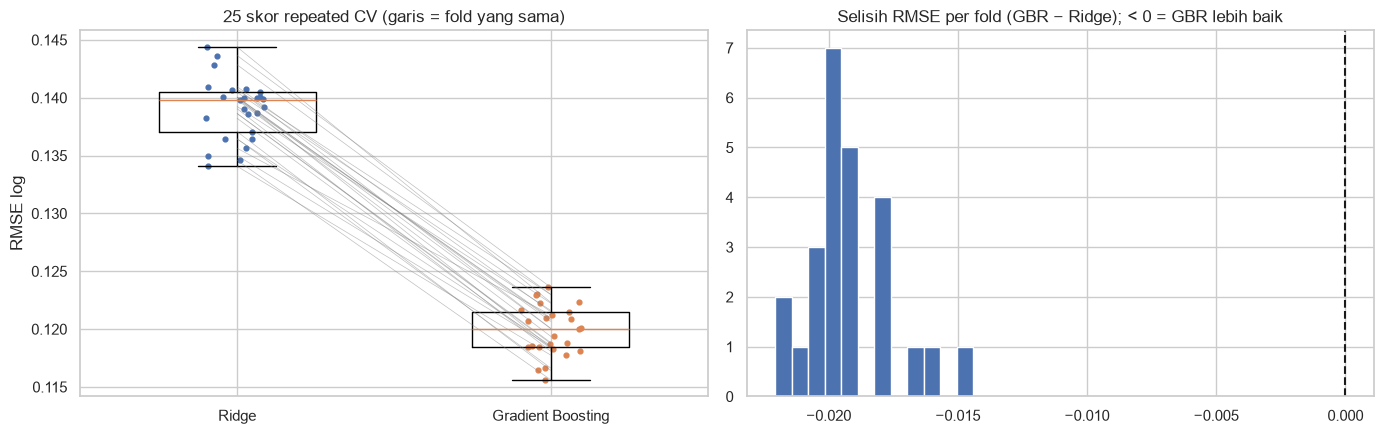

In [16]:
rmse = {n: -res["test_rmse"] for n, res in rep_results.items()}
ttest = corrected_resampled_ttest(rmse["gbr"], rmse["ridge"], N_TRAIN_FOLD, N_TEST_FOLD)
wil = stats.wilcoxon(rmse["gbr"], rmse["ridge"])
cv_tests = pd.DataFrame({
    "statistik": [stats.ttest_rel(rmse["gbr"], rmse["ridge"]).statistic, ttest["t"], wil.statistic],
    "p_value": [stats.ttest_rel(rmse["gbr"], rmse["ridge"]).pvalue, ttest["p_value"], wil.pvalue],
}, index=["t-test berpasangan naif (pembanding)", "Corrected resampled t-test (utama)", "Wilcoxon signed-rank"])
cv_tests["keputusan (α=5%)"] = np.where(cv_tests["p_value"] < 0.05, "berbeda signifikan", "tidak signifikan")
print(f"Selisih RMSE (GBR − Ridge) rata-rata {ttest['mean_diff']:+.4f}; GBR lebih baik di "
      f"{(rmse['gbr'] < rmse['ridge']).sum()} dari {len(rmse['gbr'])} fold")
display(cv_tests.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for i, n in enumerate(["ridge", "gbr"]):
    axes[0].boxplot(rmse[n], positions=[i], widths=0.5)
    axes[0].scatter(np.full(25, i) + np.random.default_rng(i).uniform(-0.1, 0.1, 25), rmse[n], s=12)
for a, b in zip(rmse["ridge"], rmse["gbr"]):
    axes[0].plot([0, 1], [a, b], color="grey", lw=0.5, alpha=0.5)
axes[0].set_xticks([0, 1], ["Ridge", "Gradient Boosting"])
axes[0].set_ylabel("RMSE log")
axes[0].set_title("25 skor repeated CV (garis = fold yang sama)")
axes[1].hist(rmse["gbr"] - rmse["ridge"], bins=12, color="#4C72B0")
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title("Selisih RMSE per fold (GBR − Ridge); < 0 = GBR lebih baik")
plt.tight_layout()
plt.show()

> **🔄 Alur data: Learning Curve**
>
> - **Input:** Konfigurasi terbaik kedua model, `X_train`.
> - **Proses:**
>   1. 7 ukuran data (10%–100%) × 5-fold → RMSE train & validasi + gap.
> - **Output:** `learning`. Ridge: gap ≈ 0,001 (tidak overfit, tetapi underfit; RMSE mentok di 0,139). GBR: gap turun 0,105 → **0,020**, dan RMSE validasi masih turun pelan (0,153 → 0,120), sehingga tambahan data masih sedikit membantu.
> - **Berikutnya:** Pilih model.

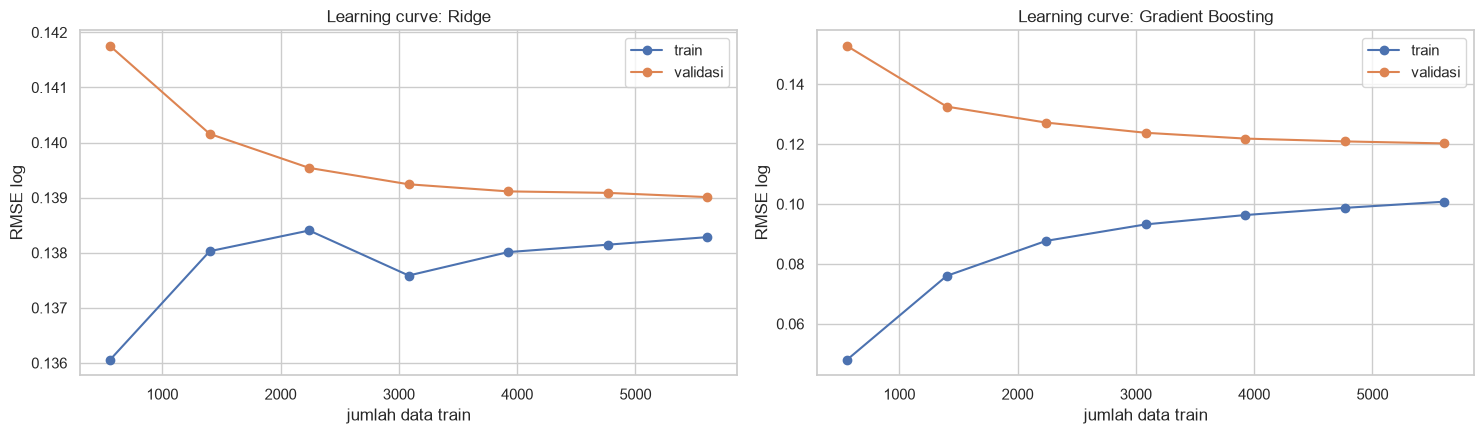

n_train  rmse_train  rmse_valid     gap
model                                           
ridge 0      560      0.1361      0.1417  0.0057
      1     1401      0.1380      0.1402  0.0021
      2     2242      0.1384      0.1395  0.0011
      3     3083      0.1376      0.1392  0.0017
      4     3924      0.1380      0.1391  0.0011
      5     4765      0.1381      0.1391  0.0009
      6     5606      0.1383      0.1390  0.0007
gbr   0      560      0.0481      0.1527  0.1047
      1     1401      0.0760      0.1325  0.0565
      2     2242      0.0877      0.1272  0.0395
      3     3083      0.0932      0.1238  0.0306
      4     3924      0.0963      0.1219  0.0255
      5     4765      0.0987      0.1209  0.0222
      6     5606      0.1008      0.1202  0.0195

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
learning = {}
for ax, (n, gs) in zip(axes, searches.items()):
    sizes, tr, va = learning_curve(clone(gs.best_estimator_), X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error",
                                   train_sizes=np.linspace(0.1, 1.0, 7), n_jobs=-1, shuffle=True, random_state=RANDOM_STATE)
    learning[n] = pd.DataFrame({"n_train": sizes, "rmse_train": -tr.mean(axis=1), "rmse_valid": -va.mean(axis=1)})
    learning[n]["gap"] = learning[n]["rmse_valid"] - learning[n]["rmse_train"]
    ax.plot(sizes, -tr.mean(axis=1), "o-", label="train")
    ax.plot(sizes, -va.mean(axis=1), "o-", label="validasi")
    ax.set_title(f"Learning curve: {MODEL_LABELS[n]}")
    ax.set_xlabel("jumlah data train")
    ax.set_ylabel("RMSE log")
    ax.legend()
plt.tight_layout()
plt.show()
pd.concat(learning, names=["model"]).round(4)

## 10. Pilih Model Terbaik

Aturan: model dengan **rata-rata RMSE repeated CV terendah**. Signifikansi (9.2) dan selisih praktis (MdAPE, PPE10) dilaporkan sebagai konteks.

> **🔄 Alur data: Pilih Model**
>
> - **Input:** `rmse` (25 skor per model), `searches`.
> - **Proses:**
>   1. Model dengan rata-rata RMSE repeated CV terendah dipilih; `best_model` = `best_estimator_` (fit di X_train).
> - **Output:** `best_name = "gbr"`, `best_model`, `other_model`. RMSE repeated CV 0,1198 vs 0,1391.
> - **Berikutnya:** Hitung interval prediksi.

In [18]:
mean_rmse = {n: rmse[n].mean() for n in rmse}
best_name = min(mean_rmse, key=mean_rmse.get)
other_name = "ridge" if best_name == "gbr" else "gbr"
best_model = searches[best_name].best_estimator_
other_model = searches[other_name].best_estimator_
print(f"Model terpilih: {MODEL_LABELS[best_name]} | RMSE repeated CV {mean_rmse[best_name]:.4f} vs {mean_rmse[other_name]:.4f}")
print(f"Hyperparameter: {searches[best_name].best_params_}")
print(f"Tren pasar terestimasi: {best_model.annual_growth_:.2%} per tahun")

Model terpilih: Gradient Boosting | RMSE repeated CV 0.1198 vs 0.1391
Hyperparameter: {'pipeline__model__learning_rate': 0.05, 'pipeline__model__max_depth': 3, 'pipeline__model__n_estimators': 600, 'pipeline__model__subsample': 0.8}
Tren pasar terestimasi: 5.96% per tahun


## 11. Interval Prediksi (Conformal)

Untuk agunan, **ketidakpastian** taksiran sama pentingnya dengan taksiran itu sendiri. Interval dibuat dengan **conformal prediction** (versi CV+):
1. `cross_val_predict` → setiap properti train diprediksi oleh model yang **tidak** melihatnya (residual out-of-fold).
2. Kuantil 5% dan 95% dari residual log → `Q_LOW`, `Q_HIGH`.
3. Interval harga = taksiran × [e^Q_LOW, e^Q_HIGH], dengan klaim cakupan ±90%.

Kelebihan conformal: tidak mengasumsikan residual berdistribusi normal, dan klaim cakupannya bisa **diuji** di test set (Bagian 12) maupun di periode berikutnya (Bagian 15).

> **🔄 Alur data: Interval Conformal**
>
> - **Input:** Konfigurasi `best_model`, `X_train`, `y_train`.
> - **Proses:**
>   1. Prediksi out-of-fold 5-fold → residual = aktual − prediksi (log).
>   2. `conformal_quantiles`: kuantil 5% & 95% (dengan koreksi n+1) → `Q_LOW`, `Q_HIGH`.
> - **Output:** `oof_pred`, `Q_LOW` = **−0,197**, `Q_HIGH` = **+0,193** → interval = taksiran × [0,821; 1,212] (−17,9% s.d. +21,2%).
> - **Berikutnya:** Evaluasi di test.

In [19]:
oof_pred = cross_val_predict(clone(best_model), X_train, y_train, cv=cv, n_jobs=-1)
oof_resid = y_train.to_numpy() - oof_pred
Q_LOW, Q_HIGH = conformal_quantiles(oof_resid, INTERVAL_COVERAGE)
print(f"Kuantil residual OOF: Q_LOW = {Q_LOW:+.4f}, Q_HIGH = {Q_HIGH:+.4f}")
print(f"→ interval harga = taksiran × [{np.exp(Q_LOW):.3f}, {np.exp(Q_HIGH):.3f}] "
      f"(≈ {np.exp(Q_LOW) - 1:+.1%} s.d. {np.exp(Q_HIGH) - 1:+.1%})")
oof_metrics = regression_metrics(y_train, oof_pred)
print(f"Metrik OOF train: MdAPE {oof_metrics['mdape']:.3f}, PPE10 {oof_metrics['ppe10']:.3f}")

Kuantil residual OOF: Q_LOW = -0.1973, Q_HIGH = +0.1926
→ interval harga = taksiran × [0.821, 1.212] (≈ -17.9% s.d. +21.2%)
Metrik OOF train: MdAPE 0.078, PPE10 0.604


## 12. Evaluasi di Test Set

> **🔄 Alur data: Metrik Test & Bootstrap CI**
>
> - **Input:** `X_test`, `y_test` (dipakai pertama kali), kedua model.
> - **Proses:**
>   1. 10 metrik untuk kedua model: RMSE/MAE/R² log, bias, MAE/RMSE rupiah, MAPE, MdAPE, PPE10, PPE20.
>   2. Bootstrap 1.000× untuk model terpilih → 95% CI.
> - **Output:** `test_pred`, `test_summary`, `final_ci`. GBR: MdAPE **7,74%** [7,21–8,29%], PPE10 **60,7%** [58,5–63,0%], PPE20 90,6%, R² 0,960, bias −0,09% [−0,67…+0,46%]. Ridge: MdAPE 8,98%, PPE10 54,7%.
> - **Berikutnya:** Uji beda kedua model & cakupan interval.

In [20]:
test_pred = best_model.predict(X_test)
other_test_pred = other_model.predict(X_test)
test_summary = pd.DataFrame({MODEL_LABELS[best_name]: regression_metrics(y_test, test_pred),
                             MODEL_LABELS[other_name]: regression_metrics(y_test, other_test_pred)}).T
display(test_summary.round(4))

final_ci = bootstrap_ci(y_test, test_pred, n_boot=1000, seed=RANDOM_STATE)
final_ci["lebar_ci"] = final_ci["ci_upper"] - final_ci["ci_lower"]
print(f"Bootstrap 95% CI ({MODEL_LABELS[best_name]}, 1.000×):")
display(final_ci.round(4))

,rmse_log,mae_log,r2_log,bias_pct,mae_juta,rmse_juta,mape,mdape,ppe10,ppe20
Gradient Boosting,0.1209,0.0946,0.9601,-0.0009,136.9831,220.1078,0.0948,0.0774,0.6070,0.9064
Ridge,0.1407,0.1092,0.9460,-0.0039,155.2601,241.8146,0.1088,0.0898,0.5465,0.8597


Bootstrap 95% CI (Gradient Boosting, 1.000×):


,estimate,ci_lower,ci_upper,std_error,lebar_ci
rmse_log,0.1209,0.1164,0.1255,0.0023,0.0091
mae_log,0.0946,0.0910,0.0982,0.0018,0.0072
r2_log,0.9601,0.9560,0.9634,0.0019,0.0074
bias_pct,-0.0009,-0.0067,0.0046,0.0029,0.0113
mae_juta,136.9831,129.5895,145.1478,4.0675,15.5583
rmse_juta,220.1078,199.5819,239.9181,10.5989,40.3363
mape,0.0948,0.0914,0.0985,0.0018,0.0071
mdape,0.0774,0.0721,0.0829,0.0027,0.0107
ppe10,0.6070,0.5847,0.6298,0.0118,0.0451
ppe20,0.9064,0.8922,0.9196,0.0071,0.0274


> **🔄 Alur data: Uji Diebold-Mariano, Wilcoxon & Cakupan Interval**
>
> - **Input:** Error kedua model pada properti test yang sama, `Q_LOW`, `Q_HIGH`.
> - **Proses:**
>   1. Paired t-test selisih kuadrat error (Diebold-Mariano) dan Wilcoxon selisih |error|.
>   2. Cakupan interval = % properti yang residualnya di dalam [Q_LOW, Q_HIGH]; uji binomial vs 90%; CI Wilson.
> - **Output:** `paired`, `test_cov`. Diebold-Mariano p < 10⁻¹⁵, Wilcoxon p < 10⁻¹⁵ (GBR lebih akurat pada 56,6% properti). Cakupan interval **89,7%** (p = 0,63): 4,4% di bawah, 5,9% di atas.
> - **Berikutnya:** Visualisasi akurasi.

In [21]:
paired = paired_error_tests(y_test.to_numpy(), test_pred, other_test_pred)
paired["keputusan (α=5%)"] = np.where(paired["p_value"] < 0.05, "berbeda signifikan", "tidak signifikan")
print(f"A = {MODEL_LABELS[best_name]}, B = {MODEL_LABELS[other_name]} (selisih negatif = A lebih akurat)")
display(paired.round(6))

test_cov = interval_coverage(y_test, test_pred, Q_LOW, Q_HIGH, INTERVAL_COVERAGE)
print(f"Cakupan interval 90% di test: {test_cov['coverage']:.1%} (95% CI {test_cov['ci_lower']:.1%}–{test_cov['ci_upper']:.1%}), "
      f"uji binomial vs 90%: p = {test_cov['p_value']:.3f} | di bawah interval {test_cov['below']:.1%}, di atas {test_cov['above']:.1%}")

A = Gradient Boosting, B = Ridge (selisih negatif = A lebih akurat)


,selisih_rata2,statistik,p_value,A_lebih_akurat_pada_%,keputusan (α=5%)
uji,,,,,
Paired t-test kuadrat error (Diebold-Mariano),-0.005168,-8.192763,0.0,0.565887,berbeda signifikan
Wilcoxon signed-rank |error|,-0.014665,605094.000000,0.0,0.565887,berbeda signifikan


Cakupan interval 90% di test: 89.7% (95% CI 88.2%–91.0%), uji binomial vs 90%: p = 0.633 | di bawah interval 4.4%, di atas 5.9%


> **🔄 Alur data: Grafik Akurasi**
>
> - **Input:** Harga aktual & taksiran test (rupiah).
> - **Proses:**
>   1. Scatter aktual vs taksiran (pita ±10%), histogram APE dengan garis PPE10/PPE20, dan interval 90% untuk ±200 properti yang diurutkan dari taksiran.
> - **Output:** 3 grafik: titik-titik mengikuti diagonal dengan sebaran kecil; mayoritas APE < 10%; titik merah (di luar interval) tersebar di semua level harga.
> - **Berikutnya:** Diagnostik residual.

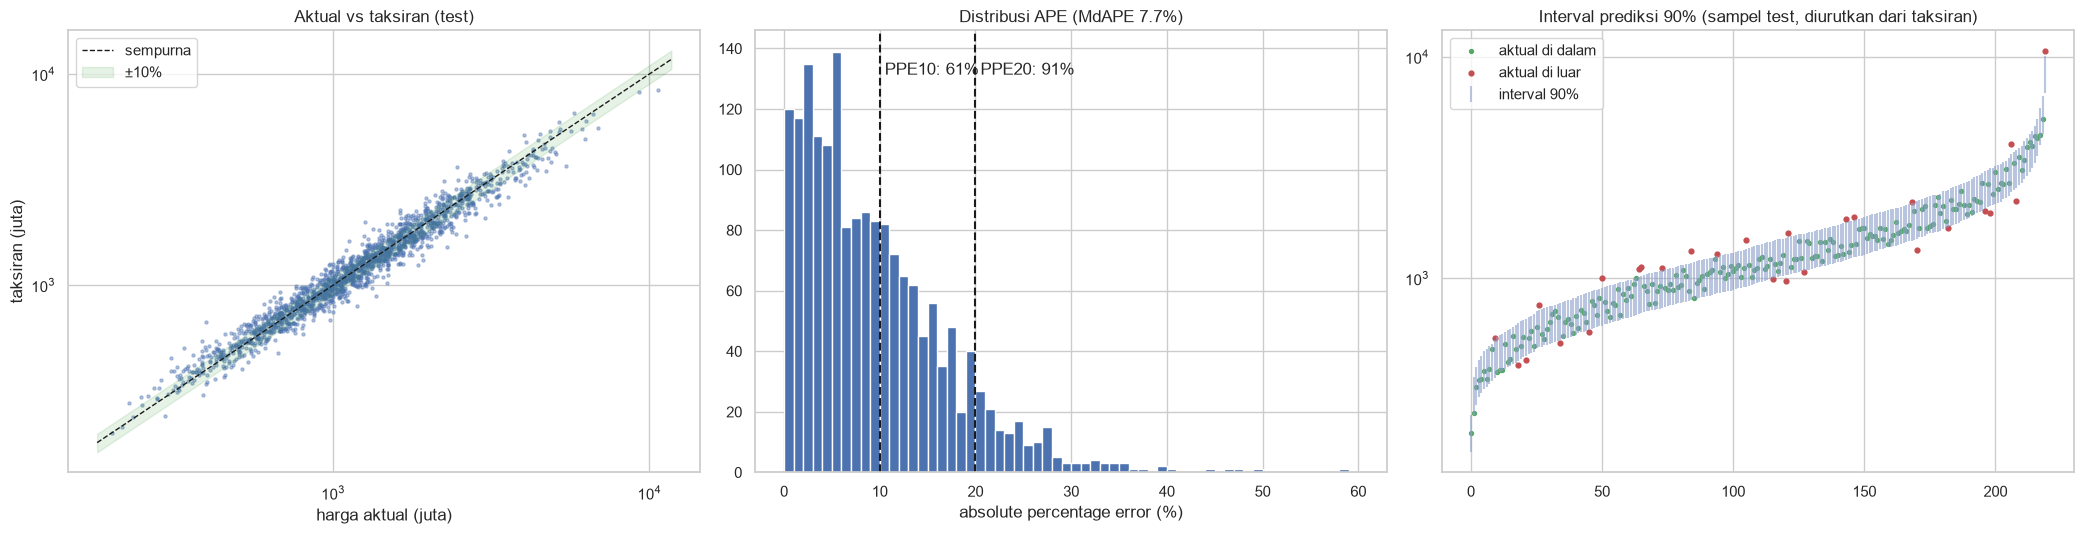

In [22]:
y_rp, p_rp = np.exp(y_test), np.exp(test_pred)
ape = np.abs(p_rp / y_rp - 1)
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))
axes[0].scatter(y_rp, p_rp, s=5, alpha=0.4)
lim = [y_rp.min() * 0.9, y_rp.max() * 1.1]
axes[0].plot(lim, lim, "k--", lw=1, label="sempurna")
axes[0].fill_between(lim, np.array(lim) * 0.9, np.array(lim) * 1.1, color="green", alpha=0.1, label="±10%")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("harga aktual (juta)")
axes[0].set_ylabel("taksiran (juta)")
axes[0].set_title("Aktual vs taksiran (test)")
axes[0].legend()
axes[1].hist(ape * 100, bins=60, range=(0, 60), color="#4C72B0")
for x, lbl in [(10, "PPE10"), (20, "PPE20")]:
    axes[1].axvline(x, color="k", ls="--")
    axes[1].text(x, axes[1].get_ylim()[1] * 0.9, f" {lbl}: {(ape <= x / 100).mean():.0%}")
axes[1].set_xlabel("absolute percentage error (%)")
axes[1].set_title(f"Distribusi APE (MdAPE {np.median(ape):.1%})")
order = np.argsort(p_rp.to_numpy() if hasattr(p_rp, "to_numpy") else p_rp)[:: max(1, len(p_rp) // 200)]
axes[2].errorbar(np.arange(len(order)), p_rp[order], yerr=[p_rp[order] * (1 - np.exp(Q_LOW)), p_rp[order] * (np.exp(Q_HIGH) - 1)],
                 fmt="none", ecolor="#8DA0CB", alpha=0.6, label="interval 90%")
inside = (np.log(y_rp.to_numpy()[order]) - test_pred[order] >= Q_LOW) & (np.log(y_rp.to_numpy()[order]) - test_pred[order] <= Q_HIGH)
axes[2].scatter(np.arange(len(order))[inside], y_rp.to_numpy()[order][inside], s=8, color="#55A868", label="aktual di dalam")
axes[2].scatter(np.arange(len(order))[~inside], y_rp.to_numpy()[order][~inside], s=12, color="#C44E52", label="aktual di luar")
axes[2].set_yscale("log")
axes[2].set_title("Interval prediksi 90% (sampel test, diurutkan dari taksiran)")
axes[2].legend()
plt.tight_layout()
plt.show()

## 13. Diagnostik Residual & Bias per Segmen

Residual = log(aktual) − log(taksiran). Residual > 0 berarti properti **ditaksir terlalu rendah**.

| Uji | H0 / ideal | Kenapa penting untuk AVM |
|---|---|---|
| **Mincer-Zarnowitz** (aktual = a + b·taksiran) | a = 0, b = 1 | b < 1: properti mahal ditaksir terlalu tinggi dan yang murah terlalu rendah |
| **Breusch-Pagan** | variance error konstan | Jika tidak konstan, interval prediksi yang lebarnya seragam akan terlalu sempit di sebagian segmen |
| **Jarque-Bera** | residual normal | Info saja. Interval conformal tidak butuh normalitas |
| **Bias per segmen** (one-sample t-test, Holm) | rata-rata residual = 0 di setiap kota/tipe/rentang harga | Bias sistematis di satu segmen = risiko kredit terkonsentrasi |

> **🔄 Alur data: Diagnostik Residual**
>
> - **Input:** Residual test.
> - **Proses:**
>   1. Mincer-Zarnowitz (F-test a = 0 & b = 1), Breusch-Pagan, Jarque-Bera.
>   2. Plot residual vs taksiran, Q-Q, dan histogram.
> - **Output:** `diagnostics`. Mincer-Zarnowitz b = **1,011**, p = 0,067 (tidak tolak ideal). Breusch-Pagan p = 0,11 (homoskedastis). Jarque-Bera p < 0,001 (ekor sedikit tebal, excess kurtosis 0,55).
> - **Berikutnya:** Cek bias per segmen.

,hasil,statistik,p_value
uji,,,
Mincer-Zarnowitz,"a = -0.079, b = 1.011 (SE 0.005)",2.7140,0.0665
Breusch-Pagan,residual² ~ taksiran + taksiran²,4.4551,0.1078
Jarque-Bera,"skew 0.076, excess kurtosis 0.550",23.7987,0.0000


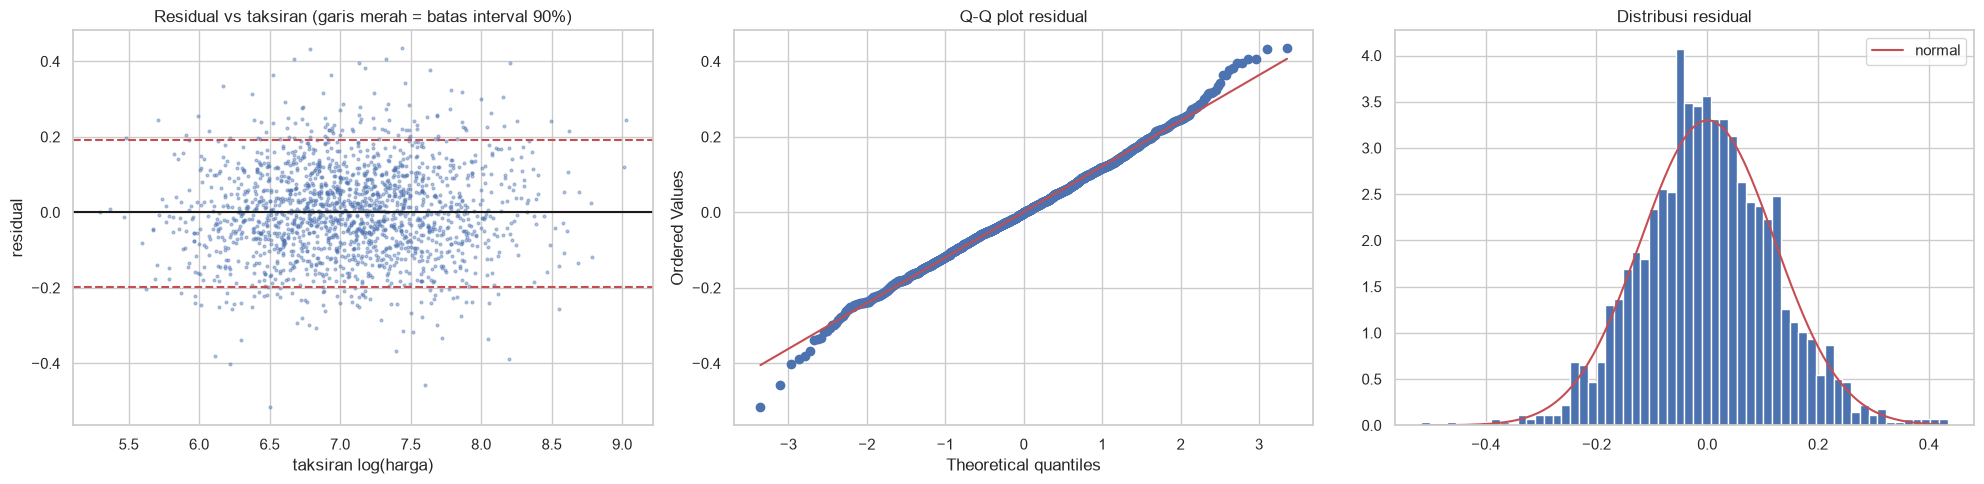

In [23]:
resid = y_test.to_numpy() - test_pred
mz = mincer_zarnowitz(y_test, test_pred)
bp = breusch_pagan(resid, test_pred)
nm = residual_normality(resid)
diagnostics = pd.DataFrame([
    {"uji": "Mincer-Zarnowitz", "hasil": f"a = {mz['intercept']:.3f}, b = {mz['slope']:.3f} (SE {mz['slope_se']:.3f})", "statistik": mz["F"], "p_value": mz["p_value"]},
    {"uji": "Breusch-Pagan", "hasil": "residual² ~ taksiran + taksiran²", "statistik": bp["LM"], "p_value": bp["p_value"]},
    {"uji": "Jarque-Bera", "hasil": f"skew {nm['skewness']:.3f}, excess kurtosis {nm['excess_kurtosis']:.3f}", "statistik": nm["jarque_bera"], "p_value": nm["p_value"]},
]).set_index("uji")
display(diagnostics.round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].scatter(test_pred, resid, s=4, alpha=0.4)
axes[0].axhline(0, color="k")
for q in (Q_LOW, Q_HIGH):
    axes[0].axhline(q, color="r", ls="--")
axes[0].set_xlabel("taksiran log(harga)")
axes[0].set_ylabel("residual")
axes[0].set_title("Residual vs taksiran (garis merah = batas interval 90%)")
stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot residual")
axes[2].hist(resid, bins=60, density=True, color="#4C72B0")
xs = np.linspace(resid.min(), resid.max(), 200)
axes[2].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()), "r", label="normal")
axes[2].set_title("Distribusi residual")
axes[2].legend()
plt.tight_layout()
plt.show()

> **🔄 Alur data: Bias per Segmen**
>
> - **Input:** `X_test`, `y_test`, `test_pred`.
> - **Proses:**
>   1. Segmen: kota, tipe, kuintil taksiran, kelompok umur bangunan, sertifikat.
>   2. Per segmen: bias %, MdAPE, PPE10, dan one-sample t-test bias = 0 (Holm per dimensi).
> - **Output:** `seg_all` (26 segmen) + grafik. **2 bias signifikan**: Surabaya −3,7% dan kuintil termurah +1,9%. Segmen lain |bias| < 2,6% dan tidak signifikan.
> - **Berikutnya:** Interpretasi model.

n  bias_pct   mdape   ppe10  p_value  p_holm           status
dimensi          segmen                                                                             
city             bandung             182    0.0055  0.0856  0.6044   0.5673  1.0000               ok
                 bekasi              210    0.0171  0.0788  0.6143   0.0314  0.2515               ok
                 bogor               142   -0.0089  0.0732  0.5845   0.3974  1.0000               ok
                 depok               166    0.0059  0.0652  0.6205   0.5006  1.0000               ok
                 jakarta_barat       174   -0.0153  0.0680  0.6494   0.0815  0.5703               ok
                 jakarta_selatan     217   -0.0026  0.0819  0.5899   0.7748  1.0000               ok
                 semarang            108    0.0258  0.0741  0.6481   0.0146  0.1317               ok
                 surabaya            185   -0.0366  0.0853  0.5730   0.0000  0.0003  bias signifikan
                 tangerang_selatan   245    0.0020  0.0847  0.5959   0.8031  1.0000               ok
                 yogyakarta          124    0.0088  0.0713  0.6129   0.3491  1.0000               ok
property_type    ruko                269   -0.0131  0.0721  0.6580   0.0601  0.1803               ok
                 rumah              1248    0.0022  0.0782  0.6002   0.5291  1.0000               ok
                 townhouse           236   -0.0031  0.0832  0.5847   0.6885  1.0000               ok
rentang_taksiran Q1 termurah         351    0.0186  0.0734  0.6068   0.0045  0.0226  bias signifikan
                 Q2                  350   -0.0072  0.0794  0.5857   0.2603  0.7810               ok
                 Q3                  351   -0.0049  0.0689  0.6439   0.4219  0.8437               ok
                 Q4                  350   -0.0129  0.0786  0.6229   0.0395  0.1581               ok
                 Q5 termahal         351    0.0022  0.0858  0.5755   0.7569  0.8437               ok
building_age_bin 16-30               397    0.0009  0.0721  0.6222   0.8814  1.0000               ok
                 6-15                853   -0.0077  0.0797  0.6026   0.0533  0.2133               ok
                 baru_0-5            326    0.0031  0.0760  0.6104   0.6397  1.0000               ok
                 missing              74    0.0387  0.0773  0.6351   0.0171  0.0854               ok
                 tua_>30             103    0.0088  0.0869  0.5534   0.5674  1.0000               ok
certificate      HGB                 441    0.0020  0.0851  0.5828   0.7360  1.0000               ok
                 SHM                1203   -0.0005  0.0748  0.6234   0.8765  1.0000               ok
                 girik_ajb           109   -0.0164  0.0807  0.5229   0.1708  0.5124               ok

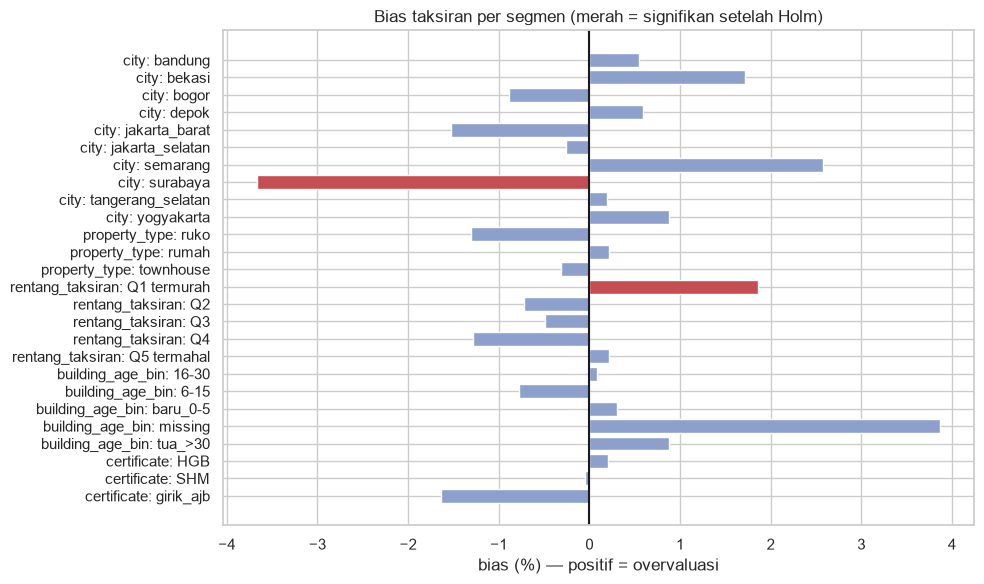

In [24]:
test_frame = X_test.assign(log_price=y_test, pred=test_pred)
test_frame["building_age_bin"] = pd.cut(test_frame["building_age"], DOMAIN_BINS["building_age"]["edges"],
                                        labels=DOMAIN_BINS["building_age"]["labels"]).astype(object).fillna("missing")
test_frame["rentang_taksiran"] = pd.qcut(np.exp(test_frame["pred"]), 5, labels=["Q1 termurah", "Q2", "Q3", "Q4", "Q5 termahal"])
segment_tables = {}
for col in ["city", "property_type", "rentang_taksiran", "building_age_bin", "certificate"]:
    segment_tables[col] = segment_bias(test_frame["log_price"], test_frame["pred"], test_frame[col])
seg_all = pd.concat(segment_tables, names=["dimensi"])
seg_all["status"] = np.where(seg_all["p_holm"] < 0.05, "bias signifikan", "ok")
display(seg_all.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = seg_all.reset_index()
plot_df["label"] = plot_df["dimensi"] + ": " + plot_df["segmen"].astype(str)
ax.barh(plot_df["label"], plot_df["bias_pct"] * 100, color=np.where(plot_df["status"] == "ok", "#8DA0CB", "#C44E52"))
ax.axvline(0, color="k")
ax.invert_yaxis()
ax.set_xlabel("bias (%) — positif = overvaluasi")
ax.set_title("Bias taksiran per segmen (merah = signifikan setelah Holm)")
plt.tight_layout()
plt.show()

### Interpretasi Evaluasi & Diagnostik

**Akurasi (Bagian 12)**
- Gradient Boosting: **MdAPE 7,7%** (95% CI 7,2–8,3%), **PPE10 60,7%** (58,5–63,0%), PPE20 90,6%, R² log 0,96. Batas CI pun memenuhi patokan praktik AVM (MdAPE ≤ 10%, PPE10 ≥ 50%).
- Dalam rupiah: rata-rata selisih absolut Rp 137 jt untuk median harga ±Rp 1,16 M.
- **Lebih akurat dari Ridge secara signifikan**: Diebold-Mariano p < 10⁻¹⁵, Wilcoxon p < 10⁻¹⁵. Namun keunggulannya bukan di semua properti: GBR lebih dekat ke harga aktual pada **56,6%** properti. Keunggulan datang dari properti yang sulit (interaksi luas × lokasi), bukan dari semua kasus.

**Interval prediksi 90%**
- Interval = taksiran × [0,82; 1,21], yaitu −18% s.d. +21%. Asimetris karena residual sedikit miring ke kanan.
- **Cakupan di test 89,7%** (CI 88,2–91,0%; binomial p = 0,63, tidak berbeda dari 90%). Yang meleset terbagi seimbang: 4,4% di bawah dan 5,9% di atas interval.

**Diagnostik residual (Bagian 13)**
- **Mincer-Zarnowitz**: slope 1,011 (SE 0,005), uji gabungan p = 0,067. Taksiran tidak bias dan skalanya tepat: properti mahal tidak ditaksir berlebihan, dan yang murah tidak ditaksir terlalu rendah.
- **Breusch-Pagan** p = 0,11, sehingga variance error tidak terbukti berubah dengan level harga. Ini membenarkan interval yang lebarnya **seragam dalam persen**.
- **Jarque-Bera** menolak normalitas (excess kurtosis 0,55: ekor sedikit lebih tebal dari normal). Ini tidak masalah karena interval conformal tidak mengasumsikan normalitas, dan cakupannya terbukti ±90%.
- **Bias per segmen**: 24 dari 26 segmen tidak bias. Dua segmen bias signifikan setelah Holm:
  - **Surabaya −3,7%** (undervaluasi; p_holm < 0,001)
  - **kuintil taksiran termurah +1,9%** (overvaluasi properti murah; p_holm = 0,02)

  Keduanya kecil dibanding MdAPE 7,7%, tetapi **sistematis**, jadi perlu dipantau. Overvaluasi properti murah sedikit berisiko bagi bank, karena agunan dinilai lebih tinggi dari harga pasar. Untuk segmen ini, plafon sebaiknya memakai `conservative_max_loan` (batas bawah interval).

## 14. Interpretasi Model

- **Permutation importance** per fitur asli: seberapa besar RMSE naik ketika satu kolom diacak.
- **Partial dependence**: taksiran rata-rata ketika satu fitur diubah-ubah, sementara fitur lain tetap seperti aslinya. Grafik ini memperlihatkan **bentuk** pengaruh tiap fitur (linear, ambang, jenuh).

> **🔄 Alur data: Permutation Importance**
>
> - **Input:** `best_model`, `X_test`, `y_test`.
> - **Proses:**
>   1. Setiap kolom (16 fitur + waktu) diacak 10× → kenaikan RMSE.
> - **Output:** `perm_df`. Terpenting: `city` (+0,33 RMSE), `land_area` (+0,28), `building_area` (+0,22), `distance_to_cbd_km` (+0,16), lalu `building_age`, waktu, kondisi, lebar jalan. `bedrooms`/`bathrooms`/`carport` ≈ 0 (informasinya sudah diwakili luas).
> - **Berikutnya:** Lihat bentuk pengaruh fitur.

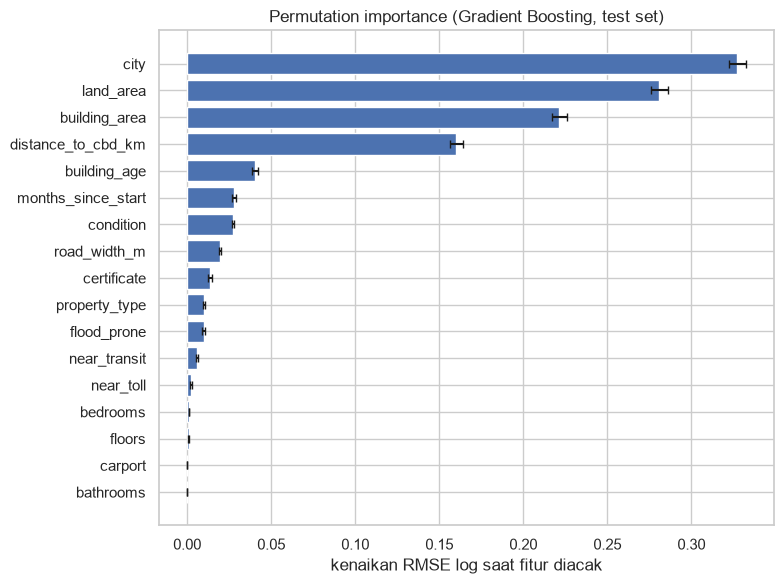

,kenaikan_rmse,std,kontribusi_nyata
city,0.3273,0.0052,ya
land_area,0.2809,0.0050,ya
building_area,0.2214,0.0046,ya
distance_to_cbd_km,0.1602,0.0039,ya
building_age,0.0404,0.0016,ya
months_since_start,0.0278,0.0012,ya
condition,0.0273,0.0007,ya
road_width_m,0.0196,0.0006,ya
certificate,0.0135,0.0011,ya
property_type,0.0100,0.0005,ya


In [25]:
perm = permutation_importance(best_model, X_test, y_test, scoring="neg_root_mean_squared_error",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({"kenaikan_rmse": perm.importances_mean, "std": perm.importances_std}, index=MODEL_INPUT)
perm_df["kontribusi_nyata"] = np.where(perm_df["kenaikan_rmse"] - 1.96 * perm_df["std"] / np.sqrt(10) > 0, "ya", "tidak")
perm_df = perm_df.sort_values("kenaikan_rmse", ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(perm_df.index, perm_df["kenaikan_rmse"], xerr=perm_df["std"], color="#4C72B0", capsize=3)
ax.invert_yaxis()
ax.set_title(f"Permutation importance ({MODEL_LABELS[best_name]}, test set)")
ax.set_xlabel("kenaikan RMSE log saat fitur diacak")
plt.tight_layout()
plt.show()
perm_df.round(4)

> **🔄 Alur data: Partial Dependence**
>
> - **Input:** 400 properti test acak, `best_model`.
> - **Proses:**
>   1. Untuk 8 fitur: nilai fitur diganti ke setiap titik grid untuk ke-400 properti, lalu taksiran rupiah dirata-rata.
> - **Output:** 8 grafik + tabel. Luas tanah 50 → 400 m²: taksiran ×3,2. Jarak 2 → 30 km: −49%. Umur 0 → 50 th: −24%. Jalan 1,5 → 15 m: +18%. Kondisi buruk → baik: +18%. Rawan banjir: −9%. Dekat transit: +6%.
> - **Berikutnya:** Mulai backtesting.

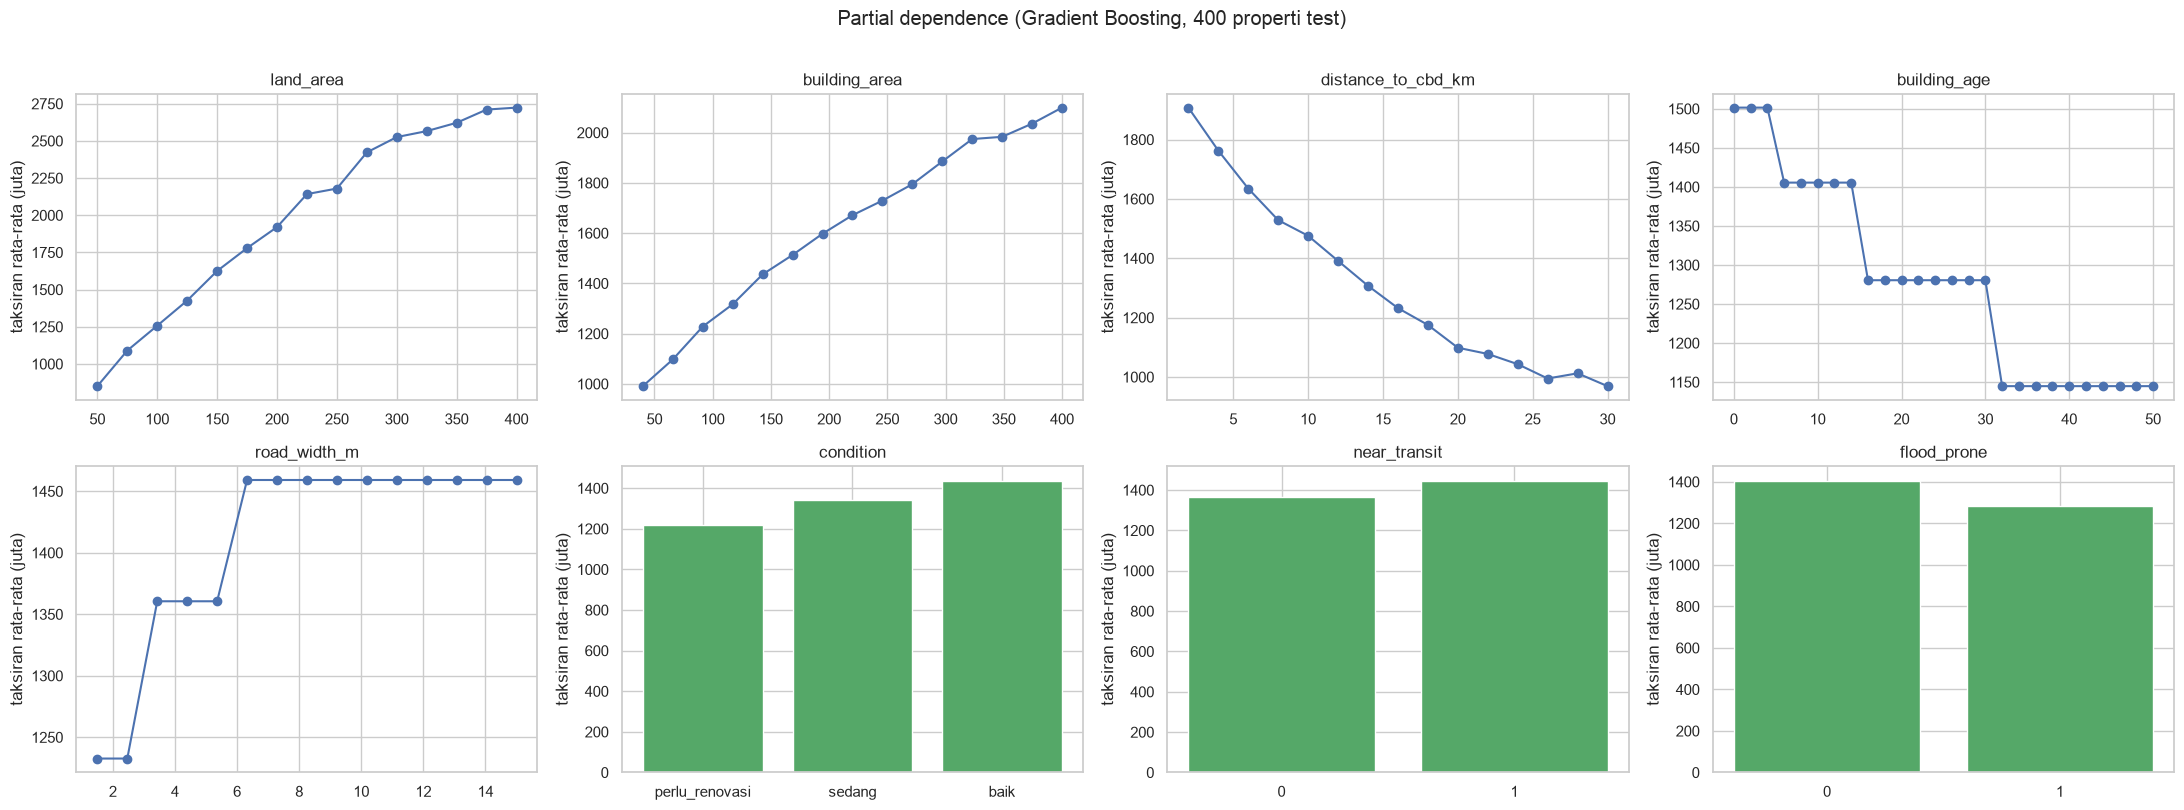

,taksiran_awal_grid,taksiran_akhir_grid,perubahan_%
land_area,850.691,2723.930,2.202
building_area,990.938,2099.674,1.119
distance_to_cbd_km,1907.626,969.203,-0.492
building_age,1501.576,1144.778,-0.238
road_width_m,1232.696,1459.178,0.184
condition,1219.577,1437.150,0.178
near_transit,1366.391,1446.569,0.059
flood_prone,1405.503,1284.233,-0.086


In [26]:
def partial_dependence(model, X, col, grid):
    out = []
    for v in grid:
        Xv = X.copy()
        Xv[col] = v
        out.append(np.exp(model.predict(Xv)).mean())
    return np.array(out)


sample = X_test.sample(400, random_state=RANDOM_STATE)
pd_specs = {
    "land_area": np.linspace(50, 400, 15), "building_area": np.linspace(40, 400, 15),
    "distance_to_cbd_km": np.linspace(2, 30, 15), "building_age": np.arange(0, 51, 2),
    "road_width_m": np.linspace(1.5, 15, 15), "condition": ["perlu_renovasi", "sedang", "baik"],
    "near_transit": [0, 1], "flood_prone": [0, 1],
}
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
pd_results = {}
for ax, (col, grid) in zip(axes.ravel(), pd_specs.items()):
    vals = partial_dependence(best_model, sample, col, grid)
    pd_results[col] = pd.Series(vals, index=grid)
    if isinstance(grid[0], str) or len(grid) <= 3:
        ax.bar([str(g) for g in grid], vals, color="#55A868")
    else:
        ax.plot(grid, vals, "o-")
    ax.set_title(col)
    ax.set_ylabel("taksiran rata-rata (juta)")
plt.suptitle(f"Partial dependence ({MODEL_LABELS[best_name]}, 400 properti test)", y=1.01)
plt.tight_layout()
plt.show()
pd.DataFrame({c: [s.iloc[0], s.iloc[-1], s.iloc[-1] / s.iloc[0] - 1] for c, s in pd_results.items()},
             index=["taksiran_awal_grid", "taksiran_akhir_grid", "perubahan_%"]).T.round(3)

## 15. Backtesting

Pertanyaan utamanya: **jika model ini dipakai kemarin, seberapa akurat taksirannya untuk transaksi hari ini?**

| # | Analisis |
|---|---|
| 15.1 | Indeks harga: tren yang diestimasi model vs median harga/m² aktual per kuartal |
| 15.2 | **Out-of-time**: latih di seluruh dev (s.d. Jun 2025), uji di Jul–Des 2025. Termasuk pembanding “waktu = fitur biasa” |
| 15.3 | **Walk-forward** expanding window: dilatih ulang setiap kuartal, diuji di kuartal berikutnya (12 kuartal: 2023Q1–2025Q4) |
| 15.4 | Stabilitas populasi: PSI taksiran & CSI fitur dev vs OOT |

> **🔄 Alur data: Indeks Harga**
>
> - **Input:** `X_dev`, `y_dev`, `df`.
> - **Proses:**
>   1. `dev_model` = konfigurasi terbaik dilatih di **seluruh dev** (train + test).
>   2. Tren hedonik model dibandingkan dengan indeks median harga/m² per kuartal.
> - **Output:** `dev_model` (fit di 8.761 baris dev), `quarters`. Tren model 5,96%/tahun → indeks 2025Q4 ≈ 125, sejalan dengan indeks aktual ≈ 125.
> - **Berikutnya:** Uji di periode out-of-time.

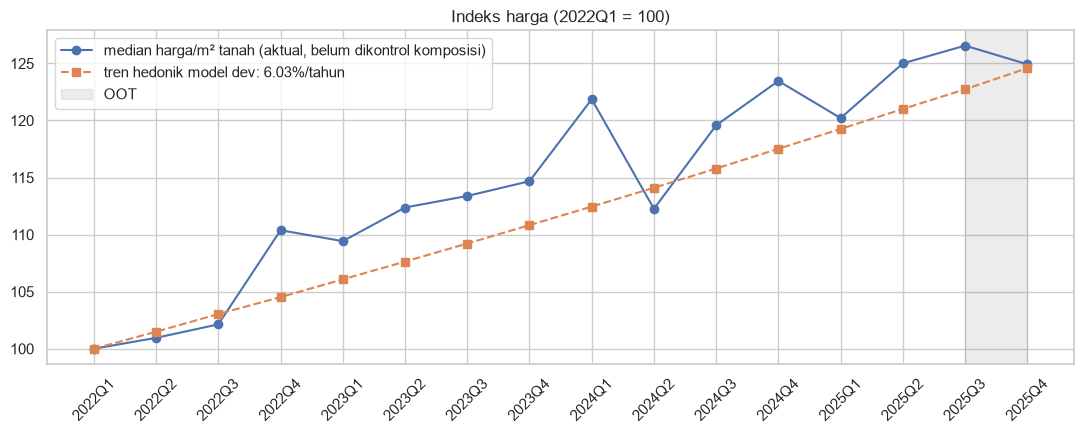

quarter,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
t,1.39,4.43,7.53,10.46,13.49,16.47,19.46,22.46,25.44,28.42,31.43,34.47,37.48,40.46,43.36,46.43
median_ppm,9.53,9.62,9.73,10.52,10.43,10.71,10.80,10.93,11.61,10.70,11.39,11.76,11.45,11.91,12.06,11.90
indeks_aktual,100.00,100.96,102.14,110.38,109.43,112.37,113.39,114.68,121.86,112.26,119.58,123.46,120.21,125.00,126.56,124.93
indeks_model,100.00,101.49,103.04,104.53,106.08,107.64,109.22,110.83,112.46,114.10,115.79,117.52,119.26,121.01,122.73,124.59


In [27]:
dev_model = clone(best_model).fit(X_dev, y_dev)
quarters = df.groupby("quarter").agg(t=(TIME_COL, "mean"), median_ppm=("price_per_m2_land", "median"))
quarters["indeks_aktual"] = quarters["median_ppm"] / quarters["median_ppm"].iloc[0] * 100
quarters["indeks_model"] = np.exp(dev_model.trend_per_month_ * (quarters["t"] - quarters["t"].iloc[0])) * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
x = quarters.index.astype(str)
ax.plot(x, quarters["indeks_aktual"], "o-", label="median harga/m² tanah (aktual, belum dikontrol komposisi)")
ax.plot(x, quarters["indeks_model"], "s--", label=f"tren hedonik model dev: {dev_model.annual_growth_:.2%}/tahun")
ax.axvspan(str(pd.Period(OOT_START, "Q")), x[-1], color="grey", alpha=0.15, label="OOT")
ax.set_title("Indeks harga (2022Q1 = 100)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
quarters.round(2).T

> **🔄 Alur data: Out-of-Time Validation**
>
> - **Input:** `dev_model`, `X_oot`, `y_oot` (dipakai pertama kali).
> - **Proses:**
>   1. Prediksi OOT dengan penyesuaian tren, dan dengan model naif (waktu = fitur biasa, hyperparameter sama).
>   2. Bootstrap CI 500×, t-test bias, cakupan interval, dan uji Diebold-Mariano tren vs naif.
> - **Output:** `oot_pred`, `oot_compare`. OOT dengan tren: MdAPE **7,98%**, PPE10 60,5%, bias **−0,03%** (p = 0,94), cakupan **89,6%**. OOT naif: bias **−4,44%** (p ≈ 4×10⁻³⁶), MdAPE 8,58%, PPE10 56,4%. Diebold-Mariano p ≈ 3×10⁻⁹.
> - **Berikutnya:** Ulangi untuk setiap kuartal.

In [28]:
oot_pred = dev_model.predict(X_oot)
naive_dev = make_naive(clone(best_model.pipeline.named_steps["model"])).fit(X_dev, y_dev)
naive_oot_pred = naive_dev.predict(X_oot)

oot_ci = bootstrap_ci(y_oot, oot_pred, n_boot=500, seed=RANDOM_STATE)
oot_compare = pd.DataFrame({
    "test (in-time)": regression_metrics(y_test, test_pred),
    "OOT: penyesuaian tren": oot_ci["estimate"],
    "OOT CI 95%": oot_ci.apply(lambda r: f"{r.ci_lower:.4f}–{r.ci_upper:.4f}", axis=1),
    "OOT: waktu = fitur biasa": regression_metrics(y_oot, naive_oot_pred),
})
display(oot_compare)

oot_bias = stats.ttest_1samp(oot_pred - y_oot, 0)
naive_bias = stats.ttest_1samp(naive_oot_pred - y_oot, 0)
oot_cov = interval_coverage(y_oot, oot_pred, Q_LOW, Q_HIGH, INTERVAL_COVERAGE)
dm_oot = paired_error_tests(y_oot.to_numpy(), oot_pred, naive_oot_pred)
print(f"Bias OOT (penyesuaian tren): {np.exp(np.mean(oot_pred - y_oot)) - 1:+.2%}, t-test p = {oot_bias.pvalue:.4f}")
print(f"Bias OOT (waktu = fitur biasa): {np.exp(np.mean(naive_oot_pred - y_oot)) - 1:+.2%}, t-test p = {naive_bias.pvalue:.2e}")
print(f"Cakupan interval 90% di OOT: {oot_cov['coverage']:.1%} (CI {oot_cov['ci_lower']:.1%}–{oot_cov['ci_upper']:.1%}), p = {oot_cov['p_value']:.3f}")
print(f"Uji DM (tren vs naif) di OOT: p = {dm_oot.iloc[0]['p_value']:.2e} | tren lebih akurat pada {dm_oot.iloc[0]['A_lebih_akurat_pada_%']:.1%} properti")

,test (in-time),OOT: penyesuaian tren,OOT CI 95%,OOT: waktu = fitur biasa
rmse_log,0.120924,0.121850,0.1168–0.1281,0.131432
mae_log,0.094578,0.095567,0.0917–0.1003,0.103747
r2_log,0.960102,0.958777,0.9540–0.9631,0.952039
bias_pct,-0.000882,-0.000261,-0.0068–0.0067,-0.044422
mae_juta,136.983086,143.028271,134.3680–151.6601,156.158831
rmse_juta,220.107790,208.604440,193.7469–223.5323,231.767871
mape,0.094823,0.096380,0.0922–0.1016,0.100203
mdape,0.077446,0.079779,0.0758–0.0856,0.085793
ppe10,0.606959,0.605327,0.5787–0.6316,0.564165
ppe20,0.906446,0.912026,0.8955–0.9274,0.895077


Bias OOT (penyesuaian tren): -0.03%, t-test p = 0.9398
Bias OOT (waktu = fitur biasa): -4.44%, t-test p = 3.92e-36
Cakupan interval 90% di OOT: 89.6% (CI 87.8%–91.2%), p = 0.636
Uji DM (tren vs naif) di OOT: p = 3.42e-09 | tren lebih akurat pada 56.2% properti


> **🔄 Alur data: Walk-Forward 12 Kuartal**
>
> - **Input:** `df`, konfigurasi `best_model`.
> - **Proses:**
>   1. Untuk setiap kuartal 2023Q1–2025Q4: latih dengan semua data sebelum kuartal itu → (1) model tren, (2) model naif, (3) OOF 3-fold untuk kuantil conformal kuartal itu.
>   2. Metrik per kuartal: MdAPE, PPE10/20, RMSE, bias + p, cakupan interval + p, bias & MdAPE model naif, tren tahunan.
>   3. Dijalankan paralel (`joblib`).
> - **Output:** `walk_forward` (12 kuartal). MdAPE 7,4–8,7% (rata-rata 8,0%), PPE10 rata-rata 60,1%, **0 kuartal bias signifikan**, cakupan rata-rata 90,8%. Bias naif rata-rata −1,4% (terburuk −5,3% di 2025Q2).
> - **Berikutnya:** Visualisasi.

In [29]:
def backtest_quarter(q, frame, estimator_template):
    train_mask = (frame["quarter"] < q).to_numpy()
    test_mask = (frame["quarter"] == q).to_numpy()
    Xtr, ytr = frame.loc[train_mask, MODEL_INPUT], frame.loc[train_mask, "log_price"]
    Xq, yq = frame.loc[test_mask, MODEL_INPUT], frame.loc[test_mask, "log_price"].to_numpy()
    trend_model = clone(estimator_template).fit(Xtr, ytr)
    naive = make_naive(clone(estimator_template.pipeline.named_steps["model"])).fit(Xtr, ytr)
    oof = cross_val_predict(clone(estimator_template), Xtr, ytr, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE))
    q_lo, q_hi = conformal_quantiles(ytr.to_numpy() - oof, INTERVAL_COVERAGE)
    p, pn = trend_model.predict(Xq), naive.predict(Xq)
    m, mn = regression_metrics(yq, p), regression_metrics(yq, pn)
    cov = interval_coverage(yq, p, q_lo, q_hi, INTERVAL_COVERAGE)
    return {"kuartal": str(q), "n_train": int(train_mask.sum()), "n_uji": int(test_mask.sum()),
            "mdape": m["mdape"], "ppe10": m["ppe10"], "ppe20": m["ppe20"], "rmse_log": m["rmse_log"],
            "bias_pct": m["bias_pct"], "bias_p": stats.ttest_1samp(p - yq, 0).pvalue,
            "coverage90": cov["coverage"], "coverage_p": cov["p_value"],
            "naif_bias_pct": mn["bias_pct"], "naif_mdape": mn["mdape"], "tren_tahunan": trend_model.annual_growth_}


wf_quarters = sorted(df["quarter"].unique())[4:]
wf_rows = Parallel(n_jobs=-1)(delayed(backtest_quarter)(q, df, best_model) for q in wf_quarters)
walk_forward = pd.DataFrame(wf_rows).set_index("kuartal")
walk_forward["bias_status"] = np.where(holm_correction(walk_forward["bias_p"]) < 0.05, "bias signifikan", "ok")
display(walk_forward.round(4))

slope = stats.linregress(np.arange(len(walk_forward)), walk_forward["mdape"])
print(f"MdAPE walk-forward: rata-rata {walk_forward['mdape'].mean():.2%} (min {walk_forward['mdape'].min():.2%}, max {walk_forward['mdape'].max():.2%}); "
      f"tren {slope.slope:+.4f}/kuartal, p = {slope.pvalue:.3f}")
print(f"PPE10 rata-rata {walk_forward['ppe10'].mean():.1%}; cakupan interval rata-rata {walk_forward['coverage90'].mean():.1%}")
print(f"Bias rata-rata: penyesuaian tren {walk_forward['bias_pct'].mean():+.2%} vs waktu = fitur biasa {walk_forward['naif_bias_pct'].mean():+.2%}")

,n_train,n_uji,mdape,ppe10,ppe20,rmse_log,bias_pct,bias_p,coverage90,coverage_p,naif_bias_pct,naif_mdape,tren_tahunan,bias_status
kuartal,,,,,,,,,,,,,,
2023Q1,2569,648,0.0870,0.5818,0.8704,0.1305,-0.0060,0.2413,0.8873,0.2943,0.0125,0.0843,0.0561,ok
2023Q2,3217,587,0.0796,0.6150,0.9097,0.1202,-0.0049,0.3206,0.9233,0.0629,-0.0306,0.0851,0.0522,ok
2023Q3,3804,635,0.0853,0.5685,0.9165,0.1223,-0.0109,0.0242,0.9024,0.8948,-0.0262,0.0834,0.0520,ok
2023Q4,4439,606,0.0782,0.6337,0.9076,0.1172,-0.0045,0.3464,0.9241,0.0493,-0.0003,0.0722,0.0582,ok
2024Q1,5045,632,0.0828,0.5934,0.9177,0.1207,-0.0011,0.8119,0.9035,0.8423,-0.0369,0.0872,0.0595,ok
2024Q2,5677,631,0.0789,0.5832,0.8954,0.1241,0.0042,0.3971,0.9002,1.0000,0.0155,0.0888,0.0606,ok
2024Q3,6308,615,0.0854,0.5561,0.9268,0.1216,-0.0116,0.0171,0.9122,0.3466,-0.0204,0.0828,0.0580,ok
2024Q4,6923,626,0.0738,0.6230,0.9153,0.1157,-0.0046,0.3148,0.9089,0.5051,0.0001,0.0735,0.0601,ok
2025Q1,7549,600,0.0769,0.6217,0.9133,0.1157,0.0089,0.0617,0.9250,0.0410,0.0208,0.0824,0.0613,ok


MdAPE walk-forward: rata-rata 8.01% (min 7.38%, max 8.70%); tren -0.0007/kuartal, p = 0.036
PPE10 rata-rata 60.1%; cakupan interval rata-rata 90.8%
Bias rata-rata: penyesuaian tren -0.29% vs waktu = fitur biasa -1.36%


> **🔄 Alur data: Grafik Walk-Forward**
>
> - **Input:** `walk_forward`.
> - **Proses:**
>   1. Akurasi, bias (tren vs naif), dan cakupan interval per kuartal.
> - **Output:** 3 grafik: MdAPE & PPE10 stabil; bias biru (tren) menempel di 0, sedangkan merah (naif) sering negatif; cakupan berfluktuasi di sekitar 90%.
> - **Berikutnya:** Cek pergeseran populasi.

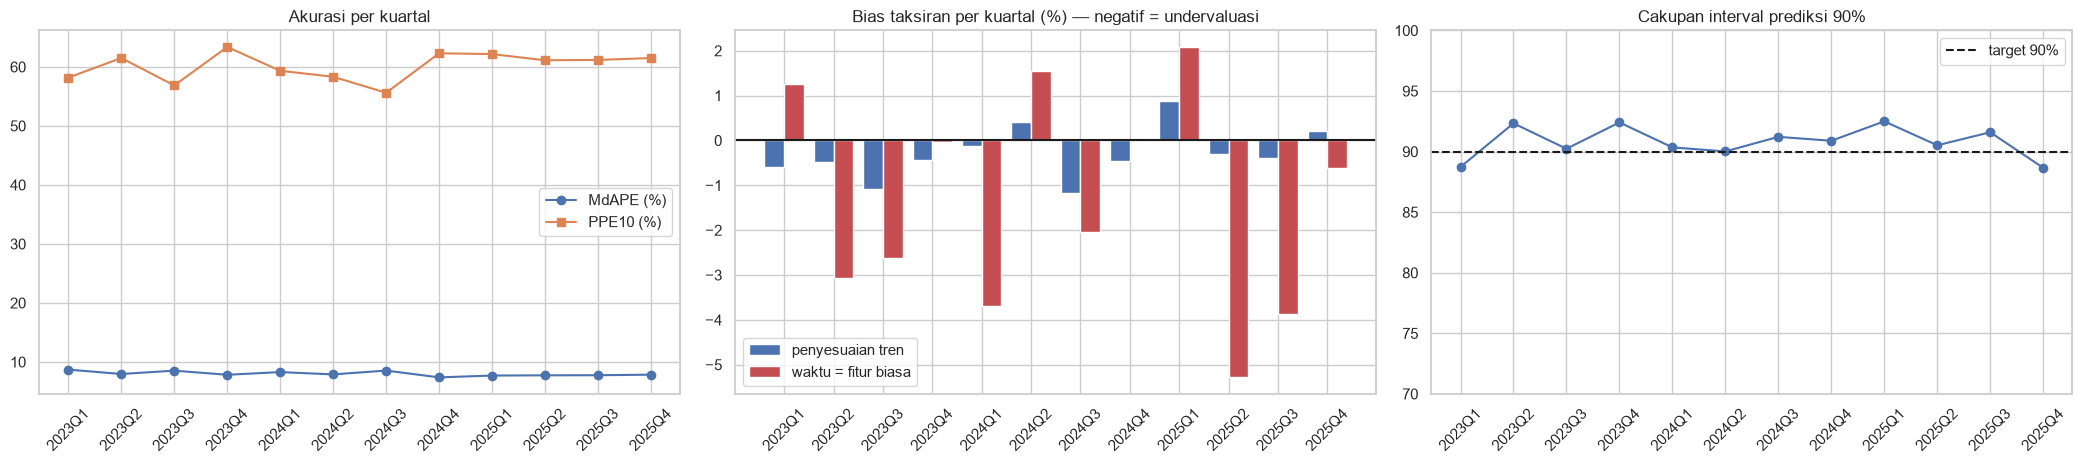

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(21, 4.8))
x = np.arange(len(walk_forward))
axes[0].plot(x, walk_forward["mdape"] * 100, "o-", label="MdAPE (%)")
axes[0].plot(x, walk_forward["ppe10"] * 100, "s-", label="PPE10 (%)")
axes[0].set_title("Akurasi per kuartal")
axes[0].legend()
axes[1].bar(x - 0.2, walk_forward["bias_pct"] * 100, 0.4, label="penyesuaian tren", color="#4C72B0")
axes[1].bar(x + 0.2, walk_forward["naif_bias_pct"] * 100, 0.4, label="waktu = fitur biasa", color="#C44E52")
axes[1].axhline(0, color="k")
axes[1].set_title("Bias taksiran per kuartal (%) — negatif = undervaluasi")
axes[1].legend()
axes[2].plot(x, walk_forward["coverage90"] * 100, "o-")
axes[2].axhline(90, color="k", ls="--", label="target 90%")
axes[2].set_ylim(70, 100)
axes[2].set_title("Cakupan interval prediksi 90%")
axes[2].legend()
for ax in axes:
    ax.set_xticks(x, walk_forward.index, rotation=45)
plt.tight_layout()
plt.show()

> **🔄 Alur data: PSI & CSI**
>
> - **Input:** `dev`, `oot`, prediksi `dev_model`.
> - **Proses:**
>   1. CSI tiap fitur (numerik: kuantil dev; kategorikal: per kategori) dan PSI distribusi taksiran.
> - **Output:** `csi_table`, `pred_psi`. PSI taksiran **0,036**; CSI semua fitur ≤ 0,012 (stabil).
> - **Berikutnya:** Rangkum semua bukti.

In [31]:
csi_rows = []
for col in FEATURES:
    v = psi_categorical(dev[col], oot[col]) if col in ONEHOT_COLS + list(ORDINAL_COLS) else psi_numeric(dev[col], oot[col])
    csi_rows.append({"fitur": col, "CSI": v, "status": stability_label(v)})
csi_table = pd.DataFrame(csi_rows).set_index("fitur").sort_values("CSI", ascending=False)
pred_psi = psi_numeric(dev_model.predict(X_dev), oot_pred)
print(f"PSI taksiran (log) dev → OOT: {pred_psi:.4f} ({stability_label(pred_psi)})")
csi_table.round(4).T

PSI taksiran (log) dev → OOT: 0.0360 (stabil)


fitur,road_width_m,distance_to_cbd_km,land_area,building_age,building_area,bedrooms,bathrooms,city,carport,certificate,condition,property_type,floors,near_toll,near_transit,flood_prone
CSI,0.0116,0.0102,0.009,0.0082,0.007,0.0068,0.0038,0.003,0.0019,0.0015,0.0008,0.0002,0.0002,0.0,0.0,0.0
status,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil,stabil


### Interpretasi Backtesting

**15.1 Tren harga**
- Model mengestimasi apresiasi **5,96%/tahun** dari data dev. Indeks hedonik model naik mulus (2022Q1 = 100 → 2025Q4 ≈ 125) dan sejalan dengan indeks median harga/m² aktual (≈ 125). Fluktuasi kuartalan pada indeks aktual sebagian besar berasal dari perubahan komposisi properti yang terjual, bukan dari perubahan harga.

**15.2 Out-of-time (Jul–Des 2025)**
- Dengan penyesuaian tren, model **sama akuratnya** di masa depan seperti di test in-time: MdAPE 8,0% (test 7,7%), PPE10 60,5% (test 60,7%), R² 0,959.
- **Bias −0,03%** (p = 0,94), tidak berbeda dari nol.
- **Cakupan interval 89,6%** (p = 0,64). Klaim “90%” tetap berlaku untuk transaksi masa depan.
- **Tanpa penyesuaian tren** (waktu sebagai fitur biasa), model yang sama **menaksir terlalu rendah 4,4%** secara sistematis (p < 10⁻³⁵), MdAPE naik ke 8,6%, dan PPE10 turun ke 56,4%. Uji Diebold-Mariano antara keduanya p < 10⁻⁸. Untuk portofolio agunan Rp 1 triliun, bias 4,4% berarti nilai agunan tercatat **Rp 44 miliar terlalu rendah**. Plafon nasabah dipotong tanpa alasan, dan revaluasi portofolio pun salah.
- Mini-backtest di Bagian 7 menunjukkan pola yang sama: bias model naif membesar seiring horizon (**−4,8% → −8,1% → −10,2%** untuk 1–6, 7–12, 13–18 bulan), sedangkan model dengan penyesuaian tren tetap di bawah 1%.

**15.3 Walk-forward 12 kuartal (2023Q1–2025Q4)**
- MdAPE per kuartal **7,4–8,7%** (rata-rata 8,0%), PPE10 rata-rata 60,1%.
- Trennya sedikit **membaik** dari waktu ke waktu (slope −0,07 poin/kuartal, p = 0,04), karena data latih terus bertambah. Ini konsisten dengan learning curve yang belum datar sepenuhnya.
- **Tidak ada kuartal dengan bias signifikan** (12/12 lolos uji setelah koreksi Holm), dengan bias rata-rata −0,3%. Model naif bias rata-rata −1,4%, dan pada beberapa kuartal −3,7% s.d. −5,3%.
- Cakupan interval rata-rata **90,8%**, antara 88,7% dan 92,5% per kuartal.
- Tren tahunan yang diestimasi stabil di 5,2–6,1% di setiap jendela waktu.

**15.4 Stabilitas**
- PSI taksiran dev → OOT **0,036**, dan CSI semua fitur < 0,012. Profil properti yang dinilai tidak berubah, dan yang bergerak hanya **level harga**, yang sudah ditangani penyesuaian tren.

**Batasan:** tren diasumsikan **linear dalam log** (pertumbuhan persentase konstan) dan sama untuk semua kota. Data generator sebenarnya punya apresiasi berbeda per kota (4,5–8%/tahun), yang ikut menjelaskan bias kecil di Surabaya (Bagian 13). Pengembangan berikutnya: tren per kota/region, atau indeks harga resmi (mis. IHPR Bank Indonesia) sebagai pengganti tren hedonik.

## 16. Ringkasan Evaluasi Statistik & Kesimpulan

> **🔄 Alur data: Ringkasan Evaluasi**
>
> - **Input:** Hasil Bagian 4–15.
> - **Proses:**
>   1. 22 pengujian dibandingkan dengan patokan → ✅/⚠️/❌ (`evaluation_summary`).
>   2. Angka kunci → `EVALUATION_FOR_METADATA`.
> - **Output:** `evaluation_summary` (22 baris): **20 ✅, 1 ⚠️** (bias 2 segmen), 1 ℹ️ (pembanding naif), 0 ❌.
> - **Berikutnya:** Model produksi.

In [32]:
def verdict(ok: bool, warn: bool = False) -> str:
    return "✅" if ok else ("⚠️" if warn else "❌")


br = rep_summary.loc[(MODEL_LABELS[best_name], "rmse")]
ci = final_ci
n_seg_bias = int((seg_all["status"] != "ok").sum())
n_wf_bias = int((walk_forward["bias_status"] != "ok").sum())
rows = [
    ("Fitur", "Fitur signifikan (Holm)", f"{(feature_tests['p_holm'] < 0.05).sum()} dari {len(feature_tests)}", "mayoritas", verdict(True)),
    ("Cross-validation", "Repeated CV RMSE log (25×)", f"{br['mean']:.4f} ± {br['std']:.4f} (CI {br['ci95_lower']:.4f}–{br['ci95_upper']:.4f})", "std < 0,01", verdict(br["std"] < 0.01)),
    ("Cross-validation", f"{MODEL_LABELS[best_name]} vs {MODEL_LABELS[other_name]} (corrected t-test)", f"Δ RMSE {ttest['mean_diff']:+.4f}, p = {ttest['p_value']:.2g}", "p < 0,05", verdict(ttest["p_value"] < 0.05, True)),
    ("Cross-validation", "Gap train–validasi (learning curve)", f"{learning[best_name]['gap'].iloc[-1]:.4f}", "< 0,03", verdict(learning[best_name]["gap"].iloc[-1] < 0.03, True)),
    ("Akurasi test", "MdAPE", f"{ci.loc['mdape', 'estimate']:.2%} (CI {ci.loc['mdape', 'ci_lower']:.2%}–{ci.loc['mdape', 'ci_upper']:.2%})", "≤ 10% (praktik AVM)", verdict(ci.loc["mdape", "ci_upper"] <= 0.10)),
    ("Akurasi test", "PPE10", f"{ci.loc['ppe10', 'estimate']:.1%} (CI {ci.loc['ppe10', 'ci_lower']:.1%}–{ci.loc['ppe10', 'ci_upper']:.1%})", "≥ 50%", verdict(ci.loc["ppe10", "ci_lower"] >= 0.5, ci.loc["ppe10", "estimate"] >= 0.5)),
    ("Akurasi test", "PPE20", f"{ci.loc['ppe20', 'estimate']:.1%}", "≥ 80%", verdict(ci.loc["ppe20", "estimate"] >= 0.8, True)),
    ("Akurasi test", "R² (log)", f"{ci.loc['r2_log', 'estimate']:.3f}", "> 0,8", verdict(ci.loc["r2_log", "estimate"] > 0.8)),
    ("Akurasi test", f"vs {MODEL_LABELS[other_name]} (Diebold-Mariano)", f"p = {paired.iloc[0]['p_value']:.2g}", "p < 0,05", verdict(paired.iloc[0]["p_value"] < 0.05, True)),
    ("Bias & kalibrasi", "Bias rata-rata test", f"{ci.loc['bias_pct', 'estimate']:+.2%} (CI {ci.loc['bias_pct', 'ci_lower']:+.2%}…{ci.loc['bias_pct', 'ci_upper']:+.2%})", "CI mencakup 0 / |bias| < 2%", verdict(abs(ci.loc["bias_pct", "estimate"]) < 0.02)),
    ("Bias & kalibrasi", "Mincer-Zarnowitz slope", f"{mz['slope']:.3f} (p = {mz['p_value']:.3f})", "0,95–1,05", verdict(0.95 <= mz["slope"] <= 1.05, 0.9 <= mz["slope"] <= 1.1)),
    ("Bias & kalibrasi", "Segmen dengan bias signifikan", f"{n_seg_bias} dari {len(seg_all)}", "0", verdict(n_seg_bias == 0, n_seg_bias <= 2)),
    ("Bias & kalibrasi", "Heteroskedastisitas (Breusch-Pagan)", f"p = {bp['p_value']:.3f}", "p > 0,05", verdict(bp["p_value"] > 0.05, True)),
    ("Interval 90%", "Cakupan di test", f"{test_cov['coverage']:.1%} (p = {test_cov['p_value']:.3f})", "≈ 90% (p > 0,05)", verdict(test_cov["p_value"] > 0.05, abs(test_cov["coverage"] - 0.9) < 0.03)),
    ("Backtest", "MdAPE OOT", f"{oot_ci.loc['mdape', 'estimate']:.2%} (test {ci.loc['mdape', 'estimate']:.2%})", "naik < 1 poin", verdict(oot_ci.loc["mdape", "estimate"] - ci.loc["mdape", "estimate"] < 0.01, True)),
    ("Backtest", "Bias OOT (penyesuaian tren)", f"{np.exp(np.mean(oot_pred - y_oot)) - 1:+.2%} (p = {oot_bias.pvalue:.3f})", "|bias| < 2%", verdict(abs(np.exp(np.mean(oot_pred - y_oot)) - 1) < 0.02)),
    ("Backtest", "Bias OOT jika waktu = fitur biasa", f"{np.exp(np.mean(naive_oot_pred - y_oot)) - 1:+.2%}", "(pembanding)", "ℹ️"),
    ("Backtest", "Cakupan interval OOT", f"{oot_cov['coverage']:.1%} (p = {oot_cov['p_value']:.3f})", "≈ 90%", verdict(oot_cov["p_value"] > 0.05, abs(oot_cov["coverage"] - 0.9) < 0.03)),
    ("Backtest", "Walk-forward MdAPE (12 kuartal)", f"{walk_forward['mdape'].mean():.2%} (maks {walk_forward['mdape'].max():.2%}), tren p = {slope.pvalue:.2f}", "maks ≤ 10%, tanpa tren naik", verdict(walk_forward["mdape"].max() <= 0.10 and not (slope.slope > 0 and slope.pvalue < 0.05))),
    ("Backtest", "Kuartal dengan bias signifikan", f"{n_wf_bias} dari {len(walk_forward)}", "0", verdict(n_wf_bias == 0, n_wf_bias <= 2)),
    ("Stabilitas", "PSI taksiran dev → OOT", f"{pred_psi:.4f}", "< 0,1", verdict(pred_psi < 0.1, pred_psi < 0.25)),
    ("Stabilitas", "CSI fitur maksimum", f"{csi_table['CSI'].max():.4f} ({csi_table['CSI'].idxmax()})", "< 0,1", verdict(csi_table["CSI"].max() < 0.1, csi_table["CSI"].max() < 0.25)),
]
evaluation_summary = pd.DataFrame(rows, columns=["aspek", "pengujian", "nilai", "patokan", "status"])
pd.set_option("display.max_colwidth", 120)
display(evaluation_summary.set_index(["aspek", "pengujian"]))
print("Rekap status:", evaluation_summary["status"].value_counts().to_dict())

EVALUATION_FOR_METADATA = {
    "repeated_cv_rmse_log": {"mean": float(br["mean"]), "std": float(br["std"]), "ci95": [float(br["ci95_lower"]), float(br["ci95_upper"])]},
    "model_comparison": {"corrected_ttest_p": float(ttest["p_value"]), "diebold_mariano_p": float(paired.iloc[0]["p_value"])},
    "test": {m: {"estimate": float(ci.loc[m, "estimate"]), "ci95": [float(ci.loc[m, "ci_lower"]), float(ci.loc[m, "ci_upper"])]}
             for m in ["mdape", "ppe10", "ppe20", "r2_log", "rmse_log", "bias_pct"]},
    "interval_coverage": {"test": float(test_cov["coverage"]), "oot": float(oot_cov["coverage"]),
                          "walk_forward_mean": float(walk_forward["coverage90"].mean())},
    "mincer_zarnowitz_slope": float(mz["slope"]),
    "backtest": {"oot_period": f"{oot[DATE_COL].min()} – {oot[DATE_COL].max()}", "oot_mdape": float(oot_ci.loc["mdape", "estimate"]),
                 "oot_bias_pct": float(np.exp(np.mean(oot_pred - y_oot)) - 1),
                 "oot_bias_naive_time_feature_pct": float(np.exp(np.mean(naive_oot_pred - y_oot)) - 1),
                 "walk_forward_mdape_mean": float(walk_forward["mdape"].mean()), "walk_forward_mdape_max": float(walk_forward["mdape"].max()),
                 "prediction_psi": float(pred_psi)},
}

nilai                      patokan status
aspek            pengujian                                                                                                            
Fitur            Fitur signifikan (Holm)                                                18 dari 18                    mayoritas      ✅
Cross-validation Repeated CV RMSE log (25×)                     0.1198 ± 0.0022 (CI 0.1174–0.1223)                   std < 0,01      ✅
                 Gradient Boosting vs Ridge (corrected t-test)           Δ RMSE -0.0192, p = 1e-16                     p < 0,05      ✅
                 Gap train–validasi (learning curve)                                        0.0195                       < 0,03      ✅
Akurasi test     MdAPE                                                      7.74% (CI 7.21%–8.29%)          ≤ 10% (praktik AVM)      ✅
                 PPE10                                                      60.7% (CI 58.5%–63.0%)                        ≥ 50%      ✅
                 PPE20                                                                       90.6%                        ≥ 80%      ✅
                 R² (log)                                                                    0.960                        > 0,8      ✅
                 vs Ridge (Diebold-Mariano)                                            p = 4.9e-16                     p < 0,05      ✅
Bias & kalibrasi Bias rata-rata test                                     -0.09% (CI -0.67%…+0.46%)  CI mencakup 0 / |bias| < 2%      ✅
                 Mincer-Zarnowitz slope                                          1.011 (p = 0.067)                    0,95–1,05      ✅
                 Segmen dengan bias signifikan                                           2 dari 26                            0     ⚠️
                 Heteroskedastisitas (Breusch-Pagan)                                     p = 0.108                     p > 0,05      ✅
Interval 90%     Cakupan di test                                                 89.7% (p = 0.633)             ≈ 90% (p > 0,05)      ✅
Backtest         MdAPE OOT                                                      7.98% (test 7.74%)                naik < 1 poin      ✅
                 Bias OOT (penyesuaian tren)                                    -0.03% (p = 0.940)                  |bias| < 2%      ✅
                 Bias OOT jika waktu = fitur biasa                                          -4.44%                 (pembanding)     ℹ️
                 Cakupan interval OOT                                            89.6% (p = 0.636)                        ≈ 90%      ✅
                 Walk-forward MdAPE (12 kuartal)                 8.01% (maks 8.70%), tren p = 0.04  maks ≤ 10%, tanpa tren naik      ✅
                 Kuartal dengan bias signifikan                                          0 dari 12                            0      ✅
Stabilitas       PSI taksiran dev → OOT                                                     0.0360                        < 0,1      ✅
                 CSI fitur maksimum                                          0.0116 (road_width_m)                        < 0,1      ✅

Rekap status: {'✅': 20, '⚠️': 1, 'ℹ️': 1}


### Kesimpulan Akhir

**Hasil: 20 ✅ · 1 ⚠️ · 0 ❌** (+1 baris pembanding ℹ️)

**1. AVM layak dipakai untuk pre-screening dan revaluasi agunan**

| Aspek | Bukti utama |
|---|---|
| **Akurasi** | MdAPE 7,7% (CI 7,2–8,3%), PPE10 60,7%, PPE20 90,6%; memenuhi patokan praktik AVM |
| **Pemilihan model** | Gradient Boosting mengungguli Ridge di 25/25 fold (corrected t-test p < 10⁻¹⁵) dan di test (Diebold-Mariano p < 10⁻¹⁵) |
| **Tidak bias** | bias −0,1% (CI mencakup 0); Mincer-Zarnowitz slope 1,01; error homoskedastis |
| **Ketidakpastian terukur** | interval 90% tercakup 89,7% (test), 89,6% (OOT), dan 90,8% (rata-rata walk-forward) |
| **Tahan waktu** | OOT MdAPE 8,0% dan bias −0,03%; walk-forward 12 kuartal tanpa bias signifikan |

**2. Pelajaran terpenting: penyesuaian tren harga.** Model berbasis pohon yang diberi waktu sebagai fitur biasa **gagal secara sistematis** di masa depan: bias −4,4% untuk 6 bulan ke depan dan sampai −10% untuk 13–18 bulan. Metrik test in-time **tidak bisa** mendeteksi masalah ini. Hanya backtesting yang bisa. Inilah alasan backtesting wajib untuk model yang dipakai melintasi waktu.

**3. Catatan ⚠️:** bias kecil tapi sistematis di Surabaya (−3,7%) dan di properti termurah (+1,9%). Untuk properti murah, gunakan **`conservative_max_loan`**. Untuk Surabaya, pertimbangkan tren harga per kota.

**4. Rekomendasi operasional**
1. Gunakan AVM untuk **pre-screening & revaluasi**. Appraisal fisik tetap diperlukan untuk agunan bernilai besar, properti atipikal (peringatan `warnings`), atau jika LTV dekat batas.
2. Untuk keputusan plafon, pakai **batas bawah interval** (`conservative_max_loan`). Peluang harga sebenarnya di bawah batas ini hanya ±5%.
3. **Refit bulanan**, karena tren harga dan bulan acuan harus mengikuti data terbaru. API memberi peringatan jika tanggal valuasi > 6 bulan setelah data terakhir.
4. **Monitoring** (lihat README): MdAPE/PPE10 per bulan, bias per kota, cakupan interval, PSI/CSI.
5. Pengembangan berikutnya: tren per kota, fitur lokasi lebih detail (koordinat, kecamatan, POI), dan validasi dengan data transaksi riil.

## 17. Model Produksi: Refit Semua Data & Export JSON

Konfigurasi yang sudah divalidasi (model + hyperparameter terbaik) dilatih ulang dengan **semua data 2022–2025** (dev + OOT), dengan dua alasan:
1. **Data terbaru paling penting** untuk properti: tren harga dan bulan acuan (`t_ref`) jadi Des 2025.
2. Data lebih banyak. Prosedurnya sudah terbukti di Bagian 9–15, jadi refit tidak mengubah validitasnya.

Interval conformal juga dihitung ulang dari residual out-of-fold di seluruh data.

> **🔄 Alur data: Refit Semua Data & Export JSON**
>
> - **Input:** Seluruh `df` (2022–2025), konfigurasi `best_model`.
> - **Proses:**
>   1. `final_model` dilatih di semua data; OOF 5-fold di semua data → `Q_LOW_FINAL`, `Q_HIGH_FINAL`.
>   2. Metadata: fitur, nilai kategori valid, rentang P1–P99 (untuk peringatan API), hyperparameter, kebijakan LTV, ringkasan evaluasi.
>   3. `export_model` → `save_json`.
> - **Output:** `final_model` (fit di 10.000 baris), tren **5,99%/tahun**, `t_ref` = bulan ke-47,9 (Des 2025), interval × [0,820; 1,210], file **`models/model.json` (373 KB)**.
> - **Berikutnya:** Buktikan JSON identik.

In [33]:
X_all, y_all = df[MODEL_INPUT], df["log_price"]
final_model = clone(best_model).fit(X_all, y_all)
all_oof = cross_val_predict(clone(best_model), X_all, y_all, cv=cv, n_jobs=-1)
Q_LOW_FINAL, Q_HIGH_FINAL = conformal_quantiles(y_all.to_numpy() - all_oof, INTERVAL_COVERAGE)

now = datetime.now(timezone.utc)
metadata = {
    "model_name": best_name,
    "model_version": now.strftime("%Y%m%d%H%M%S"),
    "trained_at": now.isoformat(timespec="seconds"),
    "training_period": f"{df[DATE_COL].min()} – {df[DATE_COL].max()}",
    "n_training_rows": int(len(df)),
    "target": "log(price), price dalam juta Rupiah",
    "features": FEATURES,
    "categorical_values": {c: sorted(df[c].dropna().unique().tolist()) for c in ONEHOT_COLS + list(ORDINAL_COLS)},
    "numeric_ranges_p1_p99": {c: [float(df[c].quantile(0.01)), float(df[c].quantile(0.99))] for c in NUMERIC_ALL},
    "best_params": {k: (v if not isinstance(v, np.generic) else v.item()) for k, v in searches[best_name].best_params_.items()},
    "ltv_policy": LTV_POLICY,
    "evaluation": EVALUATION_FOR_METADATA,
    "library_versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                         "pandas": pd.__version__, "numpy": np.__version__},
}
interval = {"coverage": INTERVAL_COVERAGE, "q_low": Q_LOW_FINAL, "q_high": Q_HIGH_FINAL, "method": "CV+ conformal (5-fold OOF residuals)"}
model_json = export_model(final_model, metadata, interval)
model_path = MODEL_DIR / "model.json"
save_json(model_json, model_path)
print(f"Tren pasar (semua data): {final_model.annual_growth_:.2%}/tahun | bulan acuan t_ref = {final_model.t_ref_:.1f}")
print(f"Interval 90%: taksiran × [{np.exp(Q_LOW_FINAL):.3f}, {np.exp(Q_HIGH_FINAL):.3f}]")
print(f"Model JSON -> {model_path} ({model_path.stat().st_size / 1024:.0f} KB), tipe {model_json['model']['type']}")

Tren pasar (semua data): 5.99%/tahun | bulan acuan t_ref = 47.9
Interval 90%: taksiran × [0.820, 1.210]
Model JSON -> /Users/ikhsannur1996/Documents/data-science/regression-e2e/models/model.json (373 KB), tipe gbr


## 18. Validasi Model JSON & Contoh Request API

> **🔄 Alur data: Validasi JSON**
>
> - **Input:** `models/model.json`, `X_all`, `X_oot`, `final_model`.
> - **Proses:**
>   1. Bandingkan log-taksiran JSON vs scikit-learn di: semua data; 50 kasus khusus (luas/umur/jalan kosong, kota `medan`, kondisi `rusak_berat`); 50 valuasi 6 bulan ke depan.
> - **Output:** Selisih maksimum ±10⁻¹⁴ di ketiga uji → **identik**.
> - **Berikutnya:** Buat contoh request.

In [34]:
json_model = JsonValuationModel.load(model_path)
diff_all = np.abs(json_model.predict_log(X_all, X_all[TIME_COL]) - final_model.predict(X_all)).max()
edge = X_oot.head(50).copy()
edge[["building_age", "road_width_m", "land_area"]] = np.nan
edge["city"] = "medan"                # kota belum pernah dilihat
edge["condition"] = "rusak_berat"      # kategori ordinal tak dikenal
diff_edge = np.abs(json_model.predict_log(edge, edge[TIME_COL]) - final_model.predict(edge)).max()
future = X_oot.head(50).assign(**{TIME_COL: final_model.t_ref_ + 6})   # valuasi 6 bulan setelah data terakhir
diff_future = np.abs(json_model.predict_log(future, future[TIME_COL]) - final_model.predict(future)).max()
print(f"Selisih maks: semua data {diff_all:.2e} | kasus khusus {diff_edge:.2e} | tanggal masa depan {diff_future:.2e}")
assert max(diff_all, diff_edge, diff_future) < 1e-8
print("✅ Model JSON identik dengan pipeline scikit-learn")

Selisih maks: semua data 2.66e-14 | kasus khusus 1.87e-14 | tanggal masa depan 1.60e-14
✅ Model JSON identik dengan pipeline scikit-learn


> **🔄 Alur data: Contoh Request API**
>
> - **Input:** `oot`, `json_model`.
> - **Proses:**
>   1. 1 properti OOT acak per tipe → payload JSON (biner → true/false, NaN → null, + `valuation_date`). Contoh pertama diberi `loan_amount` = 70% harga.
>   2. Taksiran & interval dari `JsonValuationModel` ditampilkan di samping harga aktual.
> - **Output:** `sample_request.json` (ruko Bogor + `loan_amount`) dan `sample_batch_request.json` (3 properti). Contoh: ruko Bogor harga aktual 723 jt → taksiran 740 jt [607–896].
> - **Berikutnya:** File dipakai untuk mencoba API & unit test.

In [35]:
def to_payload(row: pd.Series, date: str) -> dict:
    out = {k: (None if pd.isna(v) else (v.item() if hasattr(v, "item") else v)) for k, v in row.items()}
    for b in BINARY_COLS:
        out[b] = bool(out[b])
    return {**out, "valuation_date": date}


examples = oot.groupby("property_type").sample(1, random_state=RANDOM_STATE).reset_index(drop=True)
payloads = [{"property_id": r[ID_COL], **to_payload(r[FEATURES], r[DATE_COL])} for _, r in examples.iterrows()]
payloads[0]["loan_amount"] = round(float(examples.loc[0, TARGET]) * 0.7, 1)
(PROJECT_DIR / "sample_request.json").write_text(json.dumps(payloads[0], indent=2))
(PROJECT_DIR / "sample_batch_request.json").write_text(json.dumps({"instances": payloads}, indent=2))
check = json_model.predict_value(examples[FEATURES], examples[TIME_COL].to_numpy())
examples[[ID_COL, "city", "property_type", "land_area", "building_area", DATE_COL, TARGET]].assign(
    taksiran=check["estimate"].round(1), batas_bawah=check["lower"].round(1), batas_atas=check["upper"].round(1))

,property_id,city,property_type,land_area,building_area,transaction_date,price,taksiran,batas_bawah,batas_atas
0,P003615,bogor,ruko,77.0,115.0,2025-07-18,723.2,740.2,607.1,895.8
1,P000751,tangerang_selatan,rumah,68.0,48.0,2025-11-18,757.7,834.3,684.3,1009.7
2,P004262,semarang,townhouse,70.0,104.0,2025-11-17,697.4,778.4,638.5,942.0


## 19. Alur Data di API

```
POST /valuation  (16 fitur properti + valuation_date opsional + loan_amount opsional)
   │ 1. Pydantic (app/schemas.py): tipe, rentang, kategori valid, konsistensi
   │    (luas bangunan ≤ luas tanah × lantai × 1,1; valuation_date ≥ 2022) → gagal: HTTP 422
   ▼
   │ 2. valuation_date (default: hari ini) → months_since_start
   ▼
   │ 3. JsonValuationModel.transform: bin umur & jalan → one-hot; log1p + scaling luas/jarak;
   │    scaling jumlah ruang; biner; ordinal kondisi; one-hot kota/tipe/sertifikat → 36 kolom
   ▼
   │ 4. log(taksiran) = model(36 kolom) + g × (bulan_valuasi − bulan_acuan)
   │ 5. interval 90% = taksiran × [e^q_low, e^q_high]
   ▼
   │ 6. Plafon: LTV maks (rumah/townhouse 80%, ruko 70%) × taksiran dan × batas bawah (konservatif);
   │    jika loan_amount diisi → LTV aktual & status sesuai kebijakan
   │ 7. Peringatan: valuasi > 6 bulan setelah data terakhir, luas di luar rentang data latih (P1–P99)
   ▼
Response: estimated_value, lower_90, upper_90, price_per_m2_land, max_loan, conservative_max_loan,
          ltv (jika ada pinjaman), warnings
```

**Siklus berikutnya:** data transaksi/appraisal baru → jalankan ulang notebook (refit bulanan dianjurkan karena tren harga) → `model.json` baru → restart/rebuild API.